In [22]:
from pathlib import Path

PLAYER_NAME = "Seiya Suzuki"
MLBAM_ID = 673548

TEAM_OVERRIDE = None
POSITION_OVERRIDE = None
AGE_OVERRIDE = None
BATS_OVERRIDE = None
THROWS_OVERRIDE = None

START_DATE = "2026-3-15"
END_DATE = "2026-10-02"
REGULAR_SEASON_ONLY = True

DATA_FILE = None
DOWNLOAD_ALL_PITCHES = True
DOWNLOAD_STEP_DAYS = 5
MAX_DOWNLOAD_ATTEMPTS = 3
RECENT_REFRESH_DAYS = 10      # Re-download this moving window so recent games are not stale
FORCE_DOWNLOAD = False        # True rebuilds the download and its chunk caches

OUTPUT_DIR = Path("hitter_reports")
REPORT_THEME = "blue"       # maroon, navy, blue, green, purple, orange, or charcoal
MIN_SPLIT_PITCHES = 15
MIN_SPLIT_BIP = 5
LEAGUE_MIN_PA = 310
LEAGUE_MIN_BIP = 10
LEAGUE_MIN_SWINGS = 20
LEAGUE_MIN_FAMILY_PITCHES = 30
LEAGUE_MIN_FAMILY_BIP = 20
ROLLING_PA = 200

SWING_PLUS_FILE = Path(
    r"C:\Users\brend\OneDrive - Stonehill College\swing_plus_combined.xlsx"
)
SWING_PLUS_YEAR = None
CSWING_PLUS_OVERRIDE = None
DSWING_PLUS_OVERRIDE = None

FIELD_DIMENSIONS_OVERRIDE = None

REPORT_DPI = 320

In [23]:
import json
import re
import time
import warnings
from datetime import datetime, timedelta
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
pd.set_option("display.max_columns", 50)

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

REPORT_THEMES = {
    "maroon": ("#7A0019", "#C4CED4"),
    "navy": ("#0B1F3A", "#B8C5D6"),
    "blue": ("#1F4E79", "#BDD7EE"),
    "green": ("#1F5E46", "#C6E0D5"),
    "purple": ("#5B3A70", "#D7C9E3"),
    "orange": ("#A64B00", "#F2D1B3"),
    "charcoal": ("#30343B", "#D0D3D6"),
}
theme_key = str(REPORT_THEME).strip().lower()
if theme_key not in REPORT_THEMES:
    valid_themes = ", ".join(REPORT_THEMES)
    raise ValueError(f"Unknown REPORT_THEME '{REPORT_THEME}'. Choose: {valid_themes}")
PRIMARY_COLOR, SECONDARY_COLOR = REPORT_THEMES[theme_key]

SWING_EVENTS = {
    "swinging_strike", "swinging_strike_blocked", "foul", "foul_tip",
    "hit_into_play", "foul_bunt", "missed_bunt"
}
CONTACT_EVENTS = {"foul", "hit_into_play", "foul_bunt"}
WHIFF_EVENTS = {
    "swinging_strike", "swinging_strike_blocked", "missed_bunt",
    "foul_tip",
}

NON_AB_EVENTS = {
    "walk", "intent_walk", "hit_by_pitch", "catcher_interf",
    "sac_fly", "sac_bunt"
}
HIT_EVENTS = {"single", "double", "triple", "home_run"}

PITCH_FAMILIES = {
    "4-Seam Fastball": "Fastballs", "Sinker": "Fastballs",
    "2-Seam Fastball": "Fastballs", "Cutter": "Fastballs",
    "Slider": "Breaking", "Sweeper": "Breaking", "Curveball": "Breaking",
    "Knuckle Curve": "Breaking", "Slow Curve": "Breaking", "Slurve": "Breaking",
    "Changeup": "Offspeed", "Split-Finger": "Offspeed", "Forkball": "Offspeed",
    "Screwball": "Offspeed", "Knuckle Ball": "Other", "Eephus": "Other"
}
FAMILY_ORDER = ["Fastballs", "Breaking", "Offspeed", "Other"]
COUNT_ORDER = ["Ahead", "Even", "Behind"]
VERTICAL_ORDER = ["High", "Middle", "Low"]
HORIZONTAL_ORDER = ["Away", "Middle", "Inside"]


def slugify(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def load_local_data(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"DATA_FILE does not exist: {path}")
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path, low_memory=False)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path)
    raise ValueError("DATA_FILE must be a CSV, XLSX/XLS, or Parquet file.")


def resolve_mlbam_id(player_name, configured_id=None):
    if configured_id is not None:
        return int(configured_id)

    parts = str(player_name).strip().split()
    if len(parts) < 2:
        raise ValueError("Enter PLAYER_NAME as 'First Last' or provide MLBAM_ID.")

    try:
        from pybaseball import playerid_lookup
    except ImportError as exc:
        raise ImportError(
            "Automatic player lookup requires pybaseball. Install it or provide MLBAM_ID."
        ) from exc

    first_name = " ".join(parts[:-1])
    last_name = parts[-1]
    candidates = playerid_lookup(last_name, first_name, fuzzy=True)
    candidates = candidates.loc[candidates["key_mlbam"].notna()].copy()
    if candidates.empty:
        raise ValueError(f"No MLBAM ID found for {player_name}. Provide MLBAM_ID manually.")

    exact = candidates[
        candidates["name_first"].fillna("").str.casefold().eq(first_name.casefold())
        & candidates["name_last"].fillna("").str.casefold().eq(last_name.casefold())
    ]
    if not exact.empty:
        candidates = exact

    sort_columns = [c for c in ["mlb_played_last", "mlb_played_first"] if c in candidates]
    if sort_columns:
        candidates = candidates.sort_values(sort_columns, ascending=False)

    selected = candidates.iloc[0]
    print(
        f"Resolved {player_name} to MLBAM ID {int(selected['key_mlbam'])}. "
        "Set MLBAM_ID manually if this is not the intended player."
    )
    return int(selected["key_mlbam"])


def download_all_statcast(start_date, end_date):
    start = datetime.strptime(start_date, "%Y-%m-%d")
    requested_end = datetime.strptime(end_date, "%Y-%m-%d")
    today = datetime.now().replace(hour=0, minute=0, second=0, microsecond=0)
    end = min(requested_end, today)
    if end < start:
        raise ValueError("END_DATE must be on or after START_DATE.")
    if requested_end > today:
        print(
            f"END_DATE is in the future; downloading available data through "
            f"{end:%Y-%m-%d}."
        )

    start_text = start.strftime("%Y-%m-%d")
    end_text = end.strftime("%Y-%m-%d")
    combined_path = CACHE_DIR / f"all_statcast_{start_text}_{end_text}.pkl"
    chunk_dir = CACHE_DIR / "all_statcast_chunks"
    chunk_dir.mkdir(parents=True, exist_ok=True)

    refresh_cutoff = today - timedelta(days=max(int(RECENT_REFRESH_DAYS) - 1, 0))
    refresh_recent = int(RECENT_REFRESH_DAYS) > 0 and end >= refresh_cutoff
    if combined_path.exists() and not FORCE_DOWNLOAD and not refresh_recent:
        print(f"Loading combined full-range cache: {combined_path}")
        return pd.read_pickle(combined_path)

    try:
        from pybaseball import cache, statcast
    except ImportError as exc:
        raise ImportError(
            "Downloading Statcast data requires pybaseball. "
            "Run `pip install pybaseball` or provide DATA_FILE."
        ) from exc

    chunks = []
    current = start
    while current <= end:
        chunk_end = min(current + timedelta(days=DOWNLOAD_STEP_DAYS - 1), end)
        chunk_start_text = current.strftime("%Y-%m-%d")
        chunk_end_text = chunk_end.strftime("%Y-%m-%d")
        chunk_path = chunk_dir / f"statcast_{chunk_start_text}_{chunk_end_text}.pkl"

        refresh_chunk = (
            FORCE_DOWNLOAD
            or (int(RECENT_REFRESH_DAYS) > 0 and chunk_end >= refresh_cutoff)
        )
        if chunk_path.exists() and not refresh_chunk:
            print(f"Loading cached chunk: {chunk_start_text} to {chunk_end_text}")
            chunk = pd.read_pickle(chunk_path)
        else:
            if refresh_chunk:
                try:
                    cache.disable()
                except AttributeError:
                    pass
            else:
                cache.enable()
            chunk = None
            for attempt in range(1, MAX_DOWNLOAD_ATTEMPTS + 1):
                try:
                    print(
                        f"Downloading all pitches: {chunk_start_text} to {chunk_end_text} "
                        f"(attempt {attempt}/{MAX_DOWNLOAD_ATTEMPTS})"
                    )
                    chunk = statcast(start_dt=chunk_start_text, end_dt=chunk_end_text)
                    if chunk is None:
                        chunk = pd.DataFrame()
                    chunk.to_pickle(chunk_path)
                    break
                except Exception as exc:
                    if attempt == MAX_DOWNLOAD_ATTEMPTS:
                        raise RuntimeError(
                            f"Download failed for {chunk_start_text} to {chunk_end_text}. "
                            "Completed earlier chunks remain cached; rerun to resume."
                        ) from exc
                    wait_seconds = 3 * attempt
                    print(f"Chunk failed: {exc}. Retrying in {wait_seconds} seconds...")
                    time.sleep(wait_seconds)

        if chunk is not None and not chunk.empty:
            chunks.append(chunk)
        current = chunk_end + timedelta(days=1)

    if not chunks:
        raise ValueError("No Statcast pitches were returned for the selected date range.")

    data = pd.concat(chunks, ignore_index=True)
    dedupe_columns = [
        column for column in ["game_pk", "at_bat_number", "pitch_number"]
        if column in data.columns
    ]
    if len(dedupe_columns) == 3:
        before = len(data)
        data = data.drop_duplicates(dedupe_columns).reset_index(drop=True)
        removed = before - len(data)
        if removed:
            print(f"Removed {removed:,} duplicate pitch rows.")

    data.to_pickle(combined_path)
    print(f"Saved combined full-range cache: {combined_path}")
    return data


def download_selected_hitter(start_date, end_date, player_id):
    start = datetime.strptime(start_date, "%Y-%m-%d")
    requested_end = datetime.strptime(end_date, "%Y-%m-%d")
    today = datetime.now().replace(hour=0, minute=0, second=0, microsecond=0)
    end = min(requested_end, today)
    if end < start:
        raise ValueError("END_DATE must be on or after START_DATE.")
    if requested_end > today:
        print(
            f"END_DATE is in the future; downloading available data through "
            f"{end:%Y-%m-%d}."
        )
    start_text = start.strftime("%Y-%m-%d")
    end_text = end.strftime("%Y-%m-%d")
    cache_path = CACHE_DIR / (
        f"player_{player_id}_{start_text}_{end_text}.pkl"
    )
    refresh_cutoff = today - timedelta(days=max(int(RECENT_REFRESH_DAYS) - 1, 0))
    refresh_recent = int(RECENT_REFRESH_DAYS) > 0 and end >= refresh_cutoff
    if cache_path.exists() and not FORCE_DOWNLOAD and not refresh_recent:
        print(f"Loading cached player data: {cache_path}")
        return pd.read_pickle(cache_path)

    try:
        from pybaseball import cache, statcast_batter
    except ImportError as exc:
        raise ImportError(
            "Downloading Statcast data requires pybaseball. "
            "Run `pip install pybaseball` or provide DATA_FILE."
        ) from exc
    if FORCE_DOWNLOAD or refresh_recent:
        try:
            cache.disable()
        except AttributeError:
            pass
    else:
        cache.enable()
    print(f"Downloading Statcast data for {PLAYER_NAME} ({player_id})...")
    data = statcast_batter(start_text, end_text, player_id)
    data.to_pickle(cache_path)
    print(f"Cached player download: {cache_path}")
    return data


def load_statcast_universe():
    if DATA_FILE is not None:
        print(f"Loading local Statcast file: {DATA_FILE}")
        return load_local_data(DATA_FILE)
    if DOWNLOAD_ALL_PITCHES:
        return download_all_statcast(START_DATE, END_DATE)
    player_id = resolve_mlbam_id(PLAYER_NAME, MLBAM_ID)
    return download_selected_hitter(START_DATE, END_DATE, player_id)


def select_player(data):
    if data is None or data.empty:
        raise ValueError("The full Statcast dataset is empty.")

    player_id = MLBAM_ID
    if player_id is None and "batter" in data.columns:
        unique_ids = pd.to_numeric(data["batter"], errors="coerce").dropna().astype(int).unique()
        if len(unique_ids) == 1:
            player_id = int(unique_ids[0])
    if player_id is None:
        player_id = resolve_mlbam_id(PLAYER_NAME, player_id)

    if "batter" in data.columns:
        batter_ids = pd.to_numeric(data["batter"], errors="coerce")
        selected = data.loc[batter_ids.eq(int(player_id))].copy()
    else:
        print("Dataset has no 'batter' column; treating every row as the selected player.")
        selected = data.copy()

    if "game_date" in selected.columns:
        selected["game_date"] = pd.to_datetime(selected["game_date"], errors="coerce")
        selected = selected.loc[
            selected["game_date"].between(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE))
        ].copy()

    if REGULAR_SEASON_ONLY and "game_type" in selected.columns:
        selected = selected.loc[selected["game_type"].eq("R")].copy()

    if selected.empty:
        raise ValueError(
            f"No pitches were found for {PLAYER_NAME} ({player_id}) after filtering. "
            "Check the MLBAM ID and date range."
        )
    return selected.reset_index(drop=True), int(player_id)


def _api_json(url, timeout=8):
    request = Request(url, headers={"User-Agent": "Statcast-Hitter-Report/1.0"})
    with urlopen(request, timeout=timeout) as response:
        return json.load(response)


def _numeric_distance(value):
    if value is None:
        return np.nan
    match = re.search(r"\d+(?:\.\d+)?", str(value))
    return float(match.group()) if match else np.nan


def _sample_team_code(player_data):
    required = {"inning_topbot", "home_team", "away_team"}
    if not required.issubset(player_data.columns):
        return None
    top_bottom = player_data["inning_topbot"].fillna("").astype(str)
    batting_team = np.where(
        top_bottom.str.casefold().eq("top"),
        player_data["away_team"],
        np.where(
            top_bottom.str.casefold().eq("bot"),
            player_data["home_team"],
            np.nan,
        ),
    )
    values = pd.Series(batting_team).dropna().astype(str)
    return values.mode().iloc[0] if not values.empty else None


def resolve_player_profile(player_id, player_data):
    inferred_team_code = _sample_team_code(player_data)
    age_values = pd.to_numeric(
        player_data.get("age_bat", pd.Series(dtype=float)), errors="coerce"
    ).dropna()
    inferred_age = int(round(age_values.median())) if not age_values.empty else None
    stand_values = player_data.get("stand", pd.Series(dtype=object)).dropna().astype(str)
    inferred_bats = stand_values.mode().iloc[0] if not stand_values.empty else None

    profile = {
        "team": inferred_team_code or "Team unavailable",
        "team_code": inferred_team_code,
        "position": "Position unavailable",
        "age": inferred_age,
        "bats": inferred_bats or "—",
        "throws": "—",
        "park_name": "Generic MLB field",
        "field_dimensions": {
            "lf": 330.0, "lcf": 375.0, "cf": 400.0,
            "rcf": 375.0, "rf": 330.0,
        },
    }

    all_overrides_present = all(value is not None for value in [
        TEAM_OVERRIDE, POSITION_OVERRIDE, AGE_OVERRIDE,
        BATS_OVERRIDE, THROWS_OVERRIDE, FIELD_DIMENSIONS_OVERRIDE,
    ])

    if not all_overrides_present:
        try:
            person_payload = _api_json(
                f"https://statsapi.mlb.com/api/v1/people/{int(player_id)}"
                "?hydrate=currentTeam"
            )
            person = person_payload.get("people", [{}])[0]
            profile["position"] = (
                person.get("primaryPosition", {}).get("abbreviation")
                or person.get("primaryPosition", {}).get("name")
                or profile["position"]
            )
            profile["age"] = profile["age"] or person.get("currentAge")
            profile["bats"] = person.get("batSide", {}).get("code") or profile["bats"]
            profile["throws"] = person.get("pitchHand", {}).get("code") or profile["throws"]

            season = pd.Timestamp(END_DATE).year
            teams_payload = _api_json(
                "https://statsapi.mlb.com/api/v1/teams"
                f"?sportId=1&season={season}&hydrate=venue"
            )
            teams = teams_payload.get("teams", [])
            matching_team = next(
                (
                    team for team in teams
                    if inferred_team_code
                    and str(team.get("abbreviation", "")).casefold()
                    == str(inferred_team_code).casefold()
                ),
                None,
            )
            if matching_team is None:
                current_team_id = person.get("currentTeam", {}).get("id")
                matching_team = next(
                    (team for team in teams if team.get("id") == current_team_id),
                    None,
                )

            if matching_team:
                profile["team"] = matching_team.get("name") or profile["team"]
                profile["team_code"] = (
                    matching_team.get("abbreviation") or profile["team_code"]
                )
                venue = matching_team.get("venue", {})
                venue_id = venue.get("id")
                profile["park_name"] = venue.get("name") or profile["park_name"]
                if venue_id and FIELD_DIMENSIONS_OVERRIDE is None:
                    venue_payload = _api_json(
                        f"https://statsapi.mlb.com/api/v1/venues/{venue_id}"
                        "?hydrate=fieldInfo"
                    )
                    venue_record = venue_payload.get("venues", [{}])[0]
                    field_info = venue_record.get("fieldInfo", {})
                    dimensions = {
                        "lf": _numeric_distance(field_info.get("leftLine")),
                        "lcf": _numeric_distance(field_info.get("leftCenter")),
                        "cf": _numeric_distance(field_info.get("center")),
                        "rcf": _numeric_distance(field_info.get("rightCenter")),
                        "rf": _numeric_distance(field_info.get("rightLine")),
                    }
                    if sum(pd.notna(value) for value in dimensions.values()) >= 3:
                        defaults = profile["field_dimensions"]
                        profile["field_dimensions"] = {
                            key: dimensions[key] if pd.notna(dimensions[key]) else defaults[key]
                            for key in defaults
                        }
        except Exception as exc:
            print(
                "MLB player/venue lookup was unavailable; using Statcast and setup "
                f"fallbacks. ({exc})"
            )

    overrides = {
        "team": TEAM_OVERRIDE,
        "position": POSITION_OVERRIDE,
        "age": AGE_OVERRIDE,
        "bats": BATS_OVERRIDE,
        "throws": THROWS_OVERRIDE,
    }
    for key, value in overrides.items():
        if value is not None:
            profile[key] = value

    if FIELD_DIMENSIONS_OVERRIDE is not None:
        required = {"lf", "lcf", "cf", "rcf", "rf"}
        missing = required.difference(FIELD_DIMENSIONS_OVERRIDE)
        if missing:
            raise ValueError(
                "FIELD_DIMENSIONS_OVERRIDE is missing: " + ", ".join(sorted(missing))
            )
        profile["field_dimensions"] = {
            key: float(FIELD_DIMENSIONS_OVERRIDE[key]) for key in required
        }
        profile["park_name"] = FIELD_DIMENSIONS_OVERRIDE.get("name", "Custom field")

    return profile


In [24]:
all_statcast_df = load_statcast_universe()
print(f"Full dataset available: {len(all_statcast_df):,} pitch rows")

raw_df, RESOLVED_MLBAM_ID = select_player(all_statcast_df)
PLAYER_PROFILE = resolve_player_profile(RESOLVED_MLBAM_ID, raw_df)
latest_data_date = (
    pd.to_datetime(raw_df["game_date"], errors="coerce").max()
    if "game_date" in raw_df.columns else pd.NaT
)
print(
    f"Loaded {len(raw_df):,} Statcast rows for {PLAYER_NAME} | "
    f"{START_DATE} through {END_DATE}"
)
if pd.notna(latest_data_date):
    print(f"Latest game included: {latest_data_date:%Y-%m-%d}")
print(
    f"Profile: {PLAYER_PROFILE['team']} | {PLAYER_PROFILE['position']} | "
    f"Age {PLAYER_PROFILE['age'] or '—'} | "
    f"B/T {PLAYER_PROFILE['bats']}/{PLAYER_PROFILE['throws']}"
)
display(raw_df.head(3))


END_DATE is in the future; downloading available data through 2026-09-14.
Loading cached chunk: 2026-03-15 to 2026-03-19
Loading cached chunk: 2026-03-20 to 2026-03-24
Loading cached chunk: 2026-03-25 to 2026-03-29
Loading cached chunk: 2026-03-30 to 2026-04-03
Loading cached chunk: 2026-04-04 to 2026-04-08
Loading cached chunk: 2026-04-09 to 2026-04-13
Loading cached chunk: 2026-04-14 to 2026-04-18
Loading cached chunk: 2026-04-19 to 2026-04-23
Loading cached chunk: 2026-04-24 to 2026-04-28
Loading cached chunk: 2026-04-29 to 2026-05-03
Loading cached chunk: 2026-05-04 to 2026-05-08
Loading cached chunk: 2026-05-09 to 2026-05-13
Loading cached chunk: 2026-05-14 to 2026-05-18
Loading cached chunk: 2026-05-19 to 2026-05-23
Loading cached chunk: 2026-05-24 to 2026-05-28
Loading cached chunk: 2026-05-29 to 2026-06-02
Loading cached chunk: 2026-06-03 to 2026-06-07
Loading cached chunk: 2026-06-08 to 2026-06-12
Loading cached chunk: 2026-06-13 to 2026-06-17
Loading cached chunk: 2026-06-18 

  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\brend\AppData\Local\Programs\Python\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
 20%|██        | 1/5 [00:01<00:05,  1.38s/it]c:\Users\brend\AppData\Local\Programs\Python\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
 40%|████      | 2/5 [00:01<00:02,  1.16it/s]c:\Users\brend\AppData\Local\Programs\Python\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:5

This is a large query, it may take a moment to complete


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\brend\AppData\Local\Programs\Python\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
 20%|██        | 1/5 [00:00<00:03,  1.09it/s]c:\Users\brend\AppData\Local\Programs\Python\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
c:\Users\brend\AppData\Local\Programs\Python\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecat

This is a large query, it may take a moment to complete



 25%|██▌       | 1/4 [00:00<00:02,  1.38it/s]c:\Users\brend\AppData\Local\Programs\Python\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
 50%|█████     | 2/4 [00:01<00:01,  1.80it/s]c:\Users\brend\AppData\Local\Programs\Python\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
c:\Users\brend\AppData\Local\Programs\Python\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is

Saved combined full-range cache: hitter_reports\cache\all_statcast_2026-03-15_2026-09-14.pkl
Full dataset available: 700,526 pitch rows
Loaded 2,536 Statcast rows for Seiya Suzuki | 2026-3-15 through 2026-10-02
Latest game included: 2026-09-13
Profile: Chicago Cubs | RF | Age 32 | B/T R/R


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,...,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,SL,2026-04-13,88.0,-1.07,5.68,"Johnson, Seth",673548,686751,single,hit_into_play,<NA>,<NA>,<NA>,<NA>,4,Seiya Suzuki singles on a ground ball to left ...,R,R,R,PHI,CHC,X,7,ground_ball,2,...,-0.664,101.0,7,-7,0.997,0.003,27,31,28,32,2,4,<NA>,1,6,1,2.73,-0.51,-0.51,45.2,7.889273,-5.92635,31.539551,30.862542,36.127379
1,SL,2026-04-13,87.6,-1.15,5.68,"Johnson, Seth",673548,686751,None,called_strike,<NA>,<NA>,<NA>,<NA>,7,None,R,R,R,PHI,CHC,S,<NA>,None,2,...,0.058,<NA>,7,-7,0.997,0.003,27,31,28,32,2,4,<NA>,1,6,1,2.76,-0.53,-0.53,51.1,<NA>,<NA>,<NA>,<NA>,<NA>
2,FF,2026-04-13,95.8,-0.96,5.71,"Johnson, Seth",673548,686751,None,ball,<NA>,<NA>,<NA>,<NA>,12,None,R,R,R,PHI,CHC,B,<NA>,None,1,...,-0.022,<NA>,7,-7,0.997,0.003,27,31,28,32,2,4,<NA>,1,6,1,0.86,0.24,0.24,49.8,<NA>,<NA>,<NA>,<NA>,<NA>


In [25]:
OPTIONAL_COLUMNS = [
    "batter", "game_date", "game_type", "description", "events", "type",
    "pitch_type", "pitch_name", "p_throws", "stand", "balls", "strikes", "zone",
    "plate_x", "plate_z", "sz_top", "sz_bot", "launch_speed", "launch_angle",
    "launch_speed_angle", "estimated_ba_using_speedangle",
    "estimated_slg_using_speedangle", "estimated_woba_using_speedangle",
    "woba_value", "woba_denom", "bb_type", "hc_x", "hc_y", "hit_distance_sc",
    "bat_speed", "swing_length", "attack_angle", "attack_direction",
    "swing_path_tilt", "game_pk", "at_bat_number", "pitch_number",
    "home_team", "away_team", "inning_topbot", "age_bat",
]

NUMERIC_COLUMNS = [
    "batter", "balls", "strikes", "zone", "plate_x", "plate_z", "sz_top",
    "sz_bot", "launch_speed", "launch_angle", "launch_speed_angle",
    "estimated_ba_using_speedangle", "estimated_slg_using_speedangle",
    "estimated_woba_using_speedangle", "woba_value", "woba_denom", "hc_x",
    "hc_y", "hit_distance_sc", "bat_speed", "swing_length", "attack_angle",
    "attack_direction", "swing_path_tilt", "game_pk", "at_bat_number",
    "pitch_number", "age_bat",
]


def count_category(row):
    balls, strikes = row["balls"], row["strikes"]
    if pd.isna(balls) or pd.isna(strikes):
        return "Unknown"
    balls, strikes = int(balls), int(strikes)
    if (balls, strikes) in {(1, 0), (2, 0), (3, 0), (2, 1), (3, 1)}:
        return "Ahead"
    if (balls, strikes) in {(0, 1), (0, 2), (1, 2)}:
        return "Behind"
    if (balls, strikes) in {(0, 0), (1, 1), (2, 2), (3, 2)}:
        return "Even"
    return "Unknown"


def manual_barrel(ev, la):
    if pd.isna(ev) or pd.isna(la) or ev < 98:
        return False
    lower = max(8, 26 - (ev - 98))
    upper = min(50, 30 + 2 * (ev - 98))
    return lower <= la <= upper


def prepare_statcast_features(raw_data):
    available = [column for column in OPTIONAL_COLUMNS if column in raw_data.columns]
    data = raw_data.loc[:, available].copy()
    for column in OPTIONAL_COLUMNS:
        if column not in data.columns:
            data[column] = np.nan

    for column in NUMERIC_COLUMNS:
        data[column] = pd.to_numeric(data[column], errors="coerce").astype("float64")

    data["game_date"] = pd.to_datetime(data["game_date"], errors="coerce")
    data["description"] = data["description"].fillna("").astype(str)
    data["events"] = data["events"].where(data["events"].notna(), np.nan)
    data["pitch_name"] = data["pitch_name"].fillna("Unknown").astype(str)
    data["p_throws"] = data["p_throws"].fillna("Unknown").astype(str)
    data["stand"] = data["stand"].fillna("Unknown").astype(str)
    data["type"] = data["type"].fillna("").astype(str)

    pitch_type_values = (
        data["pitch_type"].where(data["pitch_type"].notna(), "")
        .astype(str).str.strip()
    )
    if pitch_type_values.ne("").any():
        data["is_pitch"] = pitch_type_values.ne("")
    elif data["zone"].notna().any():
        data["is_pitch"] = data["zone"].notna()
    else:
        data["is_pitch"] = True

    data["swing"] = data["description"].isin(SWING_EVENTS)
    data["contact"] = data["description"].isin(CONTACT_EVENTS) | data["type"].eq("X")
    data["whiff"] = data["description"].isin(WHIFF_EVENTS)
    data["called_strike"] = data["description"].eq("called_strike")
    data["in_zone"] = data["zone"].between(1, 9)
    data["count_group"] = data.apply(count_category, axis=1)
    data["pitch_family"] = data["pitch_name"].map(PITCH_FAMILIES).fillna("Other")

    data["plate_x_hitter"] = np.where(
        data["stand"].eq("R"), -data["plate_x"],
        np.where(data["stand"].eq("L"), data["plate_x"], np.nan),
    )
    zone_height = (data["sz_top"] - data["sz_bot"]).replace(0, np.nan)
    data["plate_z_normalized"] = (data["plate_z"] - data["sz_bot"]) / zone_height

    horizontal_away = data["plate_x_hitter"].lt(-0.28).fillna(False).to_numpy(dtype=bool)
    horizontal_inside = data["plate_x_hitter"].gt(0.28).fillna(False).to_numpy(dtype=bool)
    vertical_low = data["plate_z_normalized"].lt(1 / 3).fillna(False).to_numpy(dtype=bool)
    vertical_high = data["plate_z_normalized"].gt(2 / 3).fillna(False).to_numpy(dtype=bool)

    data["horizontal_zone"] = np.select(
        [horizontal_away, horizontal_inside], ["Away", "Inside"], default="Middle"
    )
    data["vertical_zone"] = np.select(
        [vertical_low, vertical_high], ["Low", "High"], default="Middle"
    )
    missing_location = data[["plate_x_hitter", "plate_z_normalized"]].isna().any(axis=1)
    data.loc[missing_location, ["horizontal_zone", "vertical_zone"]] = "Unknown"
    data["location_zone"] = (
        data["vertical_zone"].astype(str) + "-" + data["horizontal_zone"].astype(str)
    )

    data["in_play"] = data["description"].eq("hit_into_play") | data["type"].eq("X")
    data["is_bip"] = (
        data["in_play"] & data["launch_speed"].notna() & data["launch_angle"].notna()
    )
    if data["launch_speed_angle"].notna().any():
        data["barrel"] = data["launch_speed_angle"].eq(6) & data["is_bip"]
    else:
        data["barrel"] = [
            manual_barrel(ev, la) and is_bip
            for ev, la, is_bip in zip(
                data["launch_speed"], data["launch_angle"], data["is_bip"]
            )
        ]
    data["hard_hit"] = data["is_bip"] & data["launch_speed"].ge(95)

    data["spray_angle"] = np.nan
    data["spray_distance"] = np.nan
    data["spray_direction"] = pd.Series(pd.NA, index=data.index, dtype="object")
    spray_valid = data[["hc_x", "hc_y"]].notna().all(axis=1) & data["in_play"]
    x_field = data.loc[spray_valid, "hc_x"] - 125
    y_field = (data.loc[spray_valid, "hc_y"] - 200) * -1
    spray_angle = ((np.arctan2(y_field, x_field) / np.pi * 180) - 90) * -1

    fair_indices = spray_angle.loc[spray_angle.between(-45, 45)].index
    fair_spray = data.index.isin(fair_indices)
    data.loc[fair_spray, "spray_angle"] = spray_angle.loc[fair_indices]

    pixel_distance = np.hypot(x_field, y_field)
    tracked_distance = data.loc[spray_valid, "hit_distance_sc"]
    calibration_mask = tracked_distance.between(50, 450) & pixel_distance.ge(10)
    scale_candidates = (
        tracked_distance.loc[calibration_mask]
        .div(pixel_distance.loc[calibration_mask].replace(0, np.nan))
        .dropna()
    )
    scale_candidates = scale_candidates.loc[scale_candidates.between(1.0, 5.0)]
    coordinate_scale = scale_candidates.median() if len(scale_candidates) >= 10 else 2.7
    estimated_distance = pixel_distance * coordinate_scale
    data.loc[fair_spray, "spray_distance"] = estimated_distance.reindex(
        data.index
    ).loc[fair_spray]

    impossible_location = (
        data["spray_distance"].lt(3)
        | (
            data["events"].isin(["double", "triple", "home_run"])
            & data["spray_distance"].lt(12)
        )
    )
    data.loc[impossible_location, ["spray_angle", "spray_distance"]] = np.nan
    data["spray_distance"] = data["spray_distance"].clip(lower=0, upper=500)

    spray = pd.Series("Center", index=spray_angle.index, dtype="object")
    spray.loc[data.loc[spray_valid, "stand"].eq("R") & spray_angle.lt(-15)] = "Pull"
    spray.loc[data.loc[spray_valid, "stand"].eq("R") & spray_angle.gt(15)] = "Oppo"
    spray.loc[data.loc[spray_valid, "stand"].eq("L") & spray_angle.gt(15)] = "Pull"
    spray.loc[data.loc[spray_valid, "stand"].eq("L") & spray_angle.lt(-15)] = "Oppo"
    data.loc[spray_valid, "spray_direction"] = spray.reindex(data.index).loc[spray_valid]
    return data

df = prepare_statcast_features(raw_df)

print(
    f"Prepared {int(df['is_pitch'].sum()):,} pitches, {int(df['swing'].sum()):,} swings, "
    f"and {int(df['is_bip'].sum()):,} tracked balls in play."
)

Prepared 2,520 pitches, 1,009 swings, and 363 tracked balls in play.


In [26]:
PA_XWOBA_FALLBACK = {
    "walk": 0.69,
    "intent_walk": 0.69,
    "hit_by_pitch": 0.72,
    "single": 0.88,
    "double": 1.24,
    "triple": 1.56,
    "home_run": 2.00,
    "field_out": 0.00,
    "force_out": 0.00,
    "field_error": 0.00,
    "grounded_into_double_play": 0.00,
    "strikeout": 0.00,
    "strikeout_double_play": 0.00,
}


def build_pa_xwoba_table(data):
    terminal = data.loc[data["events"].notna()].copy()
    if terminal.empty:
        return terminal.assign(pa_xwoba=np.nan)

    if terminal["woba_denom"].notna().any():
        terminal = terminal.loc[terminal["woba_denom"].eq(1)].copy()
    else:
        terminal = terminal.loc[
            ~terminal["events"].isin(["catcher_interf", "sac_bunt"])
        ].copy()

    expected_contact = terminal["estimated_woba_using_speedangle"].where(
        terminal["in_play"]
    )
    actual_or_fallback = terminal["woba_value"].where(
        terminal["woba_value"].notna(), terminal["events"].map(PA_XWOBA_FALLBACK)
    )
    terminal["pa_xwoba"] = expected_contact.where(
        expected_contact.notna(), actual_or_fallback
    ).fillna(0.0)

    sort_columns = [
        column for column in ["game_date", "game_pk", "at_bat_number", "pitch_number"]
        if column in terminal.columns
    ]
    if sort_columns:
        terminal = terminal.sort_values(sort_columns)
    return terminal.reset_index(drop=True)


def select_competitive_swings(data):

    tracked = data.loc[
        data["swing"] & data["bat_speed"].notna()
    ].copy()
    if tracked.empty:
        return tracked

    top_swing_count = max(1, int(np.ceil(len(tracked) * 0.90)))
    top_swing_indices = tracked["bat_speed"].nlargest(
        top_swing_count, keep="first"
    ).index
    high_exit_velocity_exception = (
        tracked["bat_speed"].ge(60)
        & tracked["launch_speed"].ge(90)
    )
    competitive_mask = (
        tracked.index.isin(top_swing_indices)
        | high_exit_velocity_exception
    )
    return tracked.loc[competitive_mask].copy()


def compute_summary(data):
    data = data.copy()
    pitch_data = data.loc[data["is_pitch"]].copy()
    pitches = len(pitch_data)
    swings = int(pitch_data["swing"].sum())
    contacts = int((pitch_data["swing"] & pitch_data["contact"]).sum())
    whiffs = int((pitch_data["swing"] & pitch_data["whiff"]).sum())
    valid_zone = pitch_data["zone"].notna()
    in_zone = pitch_data["in_zone"] & valid_zone
    out_zone = (~pitch_data["in_zone"]) & valid_zone
    z_swings = int((pitch_data["swing"] & in_zone).sum())
    z_contacts = int((pitch_data["swing"] & pitch_data["contact"] & in_zone).sum())
    o_swings = int((pitch_data["swing"] & out_zone).sum())

    terminal = data.loc[data["events"].notna()].copy()
    at_bats = terminal.loc[~terminal["events"].isin(NON_AB_EVENTS)].copy()
    bip = data.loc[data["is_bip"]].copy()
    air = bip.loc[bip["bb_type"].isin(["line_drive", "fly_ball"])]
    directional_bip = bip.loc[bip["spray_direction"].notna()].copy()
    tracked_swings = data.loc[
        data["swing"] & data["bat_speed"].notna()
    ].copy()
    competitive_swings = select_competitive_swings(data)
    valid_bat_speed = competitive_swings["bat_speed"].dropna()
    pa_xwoba = build_pa_xwoba_table(data)

    xba_values = at_bats["estimated_ba_using_speedangle"].fillna(0)
    xslg_values = at_bats["estimated_slg_using_speedangle"].fillna(0)
    xwobacon_values = bip["estimated_woba_using_speedangle"].dropna()

    bb = int(terminal["events"].isin(["walk", "intent_walk"]).sum())
    hbp = int(terminal["events"].eq("hit_by_pitch").sum())
    sf = int(terminal["events"].eq("sac_fly").sum())
    strikeouts = int(terminal["events"].isin(["strikeout", "strikeout_double_play"]).sum())
    hits = int(at_bats["events"].isin(HIT_EVENTS).sum())
    total_bases = (
        at_bats["events"].eq("single").sum()
        + 2 * at_bats["events"].eq("double").sum()
        + 3 * at_bats["events"].eq("triple").sum()
        + 4 * at_bats["events"].eq("home_run").sum()
    )
    ab = len(at_bats)
    pa = len(terminal)
    obp_denominator = ab + bb + hbp + sf

    return pd.Series({
        "Pitches": pitches,
        "PA": pa,
        "AB": ab,
        "BIP": len(bip),
        "Swings": swings,
        "AVG": safe_divide(hits, ab),
        "OBP": safe_divide(hits + bb + hbp, obp_denominator),
        "SLG": safe_divide(total_bases, ab),
        "BB%": 100 * safe_divide(bb, pa),
        "K%": 100 * safe_divide(strikeouts, pa),
        "Swing%": 100 * safe_divide(swings, pitches),
        "Contact%": 100 * safe_divide(contacts, swings),
        "Whiff%": 100 * safe_divide(whiffs, swings),
        "Z-Contact%": 100 * safe_divide(z_contacts, z_swings),
        "Chase%": 100 * safe_divide(o_swings, int(out_zone.sum())),
        "CSW%": 100 * safe_divide(int((pitch_data["called_strike"] | pitch_data["whiff"]).sum()), pitches),
        "Bat-Tracked Swings": len(tracked_swings),
        "Competitive Swings": len(competitive_swings),
        "Bat Speed": valid_bat_speed.mean(),
        "Fast Swing%": 100 * valid_bat_speed.ge(75).mean() if len(valid_bat_speed) else np.nan,
        "Swing-Length Swings": int(competitive_swings["swing_length"].notna().sum()),
        "Swing Length": competitive_swings["swing_length"].mean(),
        "Attack Angle": competitive_swings["attack_angle"].mean(),
        "Attack Direction": competitive_swings["attack_direction"].mean(),
        "Swing Path Tilt": competitive_swings["swing_path_tilt"].mean(),
        "EV": bip["launch_speed"].mean(),
        "LA": bip["launch_angle"].mean(),
        "HH%": 100 * bip["hard_hit"].mean() if len(bip) else np.nan,
        "Barrel%": 100 * bip["barrel"].mean() if len(bip) else np.nan,
        "EV90": bip["launch_speed"].quantile(0.90) if len(bip) >= 5 else np.nan,
        "Max EV": bip["launch_speed"].max(),
        "Air EV": air["launch_speed"].mean(),
        "xBA": xba_values.mean() if len(xba_values) else np.nan,
        "xSLG": xslg_values.mean() if len(xslg_values) else np.nan,
        "xwOBA": pa_xwoba["pa_xwoba"].mean() if len(pa_xwoba) else np.nan,
        "xwOBAcon": xwobacon_values.mean() if len(xwobacon_values) else np.nan,
        "GB%": 100 * bip["bb_type"].eq("ground_ball").mean() if len(bip) else np.nan,
        "LD%": 100 * bip["bb_type"].eq("line_drive").mean() if len(bip) else np.nan,
        "FB%": 100 * bip["bb_type"].eq("fly_ball").mean() if len(bip) else np.nan,
        "PU%": 100 * bip["bb_type"].eq("popup").mean() if len(bip) else np.nan,
        "Pull%": 100 * directional_bip["spray_direction"].eq("Pull").mean() if len(directional_bip) else np.nan,
        "Center%": 100 * directional_bip["spray_direction"].eq("Center").mean() if len(directional_bip) else np.nan,
        "Oppo%": 100 * directional_bip["spray_direction"].eq("Oppo").mean() if len(directional_bip) else np.nan,
    })


def build_split(data, column, order=None, include_overall=False,
                minimum_pitches=MIN_SPLIT_PITCHES):
    rows = []
    if include_overall:
        overall_row = compute_summary(data)
        overall_row.name = "Overall"
        rows.append(overall_row)

    keys = order if order is not None else data[column].dropna().unique().tolist()
    for key in keys:
        subset = data.loc[data[column].eq(key)]
        if int(subset["is_pitch"].sum()) < minimum_pitches:
            continue
        summary = compute_summary(subset)
        summary.name = key
        if summary["BIP"] < MIN_SPLIT_BIP:
            for metric in [
                "EV", "LA", "HH%", "Barrel%", "EV90", "Max EV", "Air EV",
                "xwOBAcon", "GB%", "LD%", "FB%", "PU%", "Pull%", "Center%", "Oppo%",
            ]:
                summary[metric] = np.nan
        rows.append(summary)
    return pd.DataFrame(rows)


def selected_bat_side(data):
    sides = data.loc[data["stand"].isin(["L", "R"]), "stand"]
    return sides.mode().iloc[0] if not sides.empty else "Unknown"


def clean_swing_plus_name(value):
    if pd.isna(value):
        return ""
    value = str(value).replace("’", "'")
    value = re.sub(r"\b(Jr|Sr|II|III|IV)\.?$", "", value, flags=re.IGNORECASE)
    value = value.replace(".", "")
    value = re.sub(r"\s+", " ", value).lower().strip()
    name_fixes = {
        "cj abrams": "carl abrams",
        "joshua palacios": "josh palacios",
        "yuli gurriel": "yulieski gurriel",
        "gio urshela": "giovanny urshela",
        "michael siani": "mike siani",
    }
    return name_fixes.get(value, value)


def load_swing_plus_scores(player_name, season, batting_side):
    cswing = pd.to_numeric(CSWING_PLUS_OVERRIDE, errors="coerce")
    dswing = pd.to_numeric(DSWING_PLUS_OVERRIDE, errors="coerce")
    source_note = "manual override" if pd.notna(cswing) or pd.notna(dswing) else None

    needs_file = pd.isna(cswing) or pd.isna(dswing)
    path = Path(SWING_PLUS_FILE) if SWING_PLUS_FILE is not None else None
    if needs_file and path is not None and path.exists():
        suffix = path.suffix.lower()
        if suffix in {".xlsx", ".xls"}:
            swing_plus = pd.read_excel(path)
        elif suffix == ".csv":
            swing_plus = pd.read_csv(path, low_memory=False)
        elif suffix in {".parquet", ".pq"}:
            swing_plus = pd.read_parquet(path)
        else:
            raise ValueError("SWING_PLUS_FILE must be Excel, CSV, or Parquet.")

        column_lookup = {str(column).strip().casefold(): column for column in swing_plus.columns}
        required = {"year", "name", "cswing+", "dswing+"}
        missing = sorted(required - set(column_lookup))
        if missing:
            raise ValueError(
                "SWING_PLUS_FILE is missing required columns: " + ", ".join(missing)
            )

        year_column = column_lookup["year"]
        name_column = column_lookup["name"]
        cswing_column = column_lookup["cswing+"]
        dswing_column = column_lookup["dswing+"]
        swing_plus["_year"] = pd.to_numeric(swing_plus[year_column], errors="coerce")
        swing_plus["_name_clean"] = swing_plus[name_column].map(clean_swing_plus_name)
        matches = swing_plus.loc[
            swing_plus["_year"].eq(int(season))
            & swing_plus["_name_clean"].eq(clean_swing_plus_name(player_name))
        ].copy()

        side_column = column_lookup.get("side")
        if side_column is not None and batting_side in {"L", "R"}:
            side_matches = matches.loc[
                matches[side_column].fillna("").astype(str).str.upper().eq(batting_side)
            ]
            if not side_matches.empty:
                matches = side_matches

        if not matches.empty:
            selected = matches.iloc[0]
            if pd.isna(cswing):
                cswing = pd.to_numeric(selected[cswing_column], errors="coerce")
            if pd.isna(dswing):
                dswing = pd.to_numeric(selected[dswing_column], errors="coerce")
            source_note = path.name
        else:
            print(
                f"No Swing+ row found for {player_name}, {season}, {batting_side}HB in {path}."
            )
    elif needs_file and path is not None:
        print(
            f"Swing+ workbook not found: {path}. Run Swing_Models.ipynb, "
            "change SWING_PLUS_FILE, or enter the two override values in Setup."
        )

    if pd.notna(cswing) or pd.notna(dswing):
        print(
            f"Swing+ loaded for {player_name} ({season}, {batting_side}HB)"
            + (f" from {source_note}." if source_note else ".")
        )
    return float(cswing) if pd.notna(cswing) else np.nan, float(dswing) if pd.notna(dswing) else np.nan


overall = compute_summary(df)
hand_splits = build_split(df, "p_throws", ["R", "L"], include_overall=True)
count_splits = build_split(df, "count_group", COUNT_ORDER, include_overall=True)
PITCH_FAMILY_REPORT_ORDER = ["Fastballs", "Breaking", "Offspeed"]
pitch_splits = build_split(
    df, "pitch_family", PITCH_FAMILY_REPORT_ORDER, include_overall=False
)

SELECTED_BAT_SIDE = selected_bat_side(df)
SWING_PLUS_SEASON_USED = (
    int(SWING_PLUS_YEAR) if SWING_PLUS_YEAR is not None
    else pd.Timestamp(END_DATE).year
)
CSWING_PLUS, DSWING_PLUS = load_swing_plus_scores(
    PLAYER_NAME, SWING_PLUS_SEASON_USED, SELECTED_BAT_SIDE
)
overall["cSwing+"] = CSWING_PLUS
overall["dSwing+"] = DSWING_PLUS
league_mask = pd.Series(True, index=all_statcast_df.index)
if "stand" in all_statcast_df.columns:
    league_mask &= all_statcast_df["stand"].fillna("Unknown").astype(str).eq(SELECTED_BAT_SIDE)
if "game_date" in all_statcast_df.columns:
    league_dates = pd.to_datetime(all_statcast_df["game_date"], errors="coerce")
    league_mask &= league_dates.between(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE))
if REGULAR_SEASON_ONLY and "game_type" in all_statcast_df.columns:
    league_mask &= all_statcast_df["game_type"].eq("R")

league_df = prepare_statcast_features(all_statcast_df.loc[league_mask].copy())
LEAGUE_HITTER_COUNT = int(league_df["batter"].nunique()) if not league_df.empty else 0
LEAGUE_BENCHMARK_AVAILABLE = LEAGUE_HITTER_COUNT >= 20

league_summary_rows = []
if LEAGUE_BENCHMARK_AVAILABLE:
    for batter_id, hitter_data in league_df.groupby("batter", sort=False):
        hitter_summary = compute_summary(hitter_data)
        hitter_summary["Batter"] = batter_id
        league_summary_rows.append(hitter_summary)
league_hitter_summaries = pd.DataFrame(league_summary_rows)
if not league_hitter_summaries.empty:
    league_hitter_summaries = league_hitter_summaries.loc[
        league_hitter_summaries["PA"].ge(LEAGUE_MIN_PA)
        & league_hitter_summaries["BIP"].ge(LEAGUE_MIN_BIP)
        & league_hitter_summaries["Swings"].ge(LEAGUE_MIN_SWINGS)
    ].reset_index(drop=True)

LEAGUE_PERCENTILES_AVAILABLE = len(league_hitter_summaries) >= 20
PERCENTILE_HIGHER_IS_BETTER = {
    "K%": False,
    "Whiff%": False,
    "Chase%": False,
}


def metric_percentile(metric, value):
    if not LEAGUE_PERCENTILES_AVAILABLE or pd.isna(value):
        return np.nan
    values = pd.to_numeric(league_hitter_summaries[metric], errors="coerce").dropna()
    if len(values) < 20:
        return np.nan
    percentile = 100 * (
        values.lt(value).sum() + 0.5 * values.eq(value).sum()
    ) / len(values)
    if not PERCENTILE_HIGHER_IS_BETTER.get(metric, True):
        percentile = 100 - percentile
    return float(np.clip(percentile, 0, 100))


PITCH_BENCHMARK_METRICS = [
    "Swing%", "Contact%", "Chase%", "EV", "HH%", "Barrel%",
    "xBA", "xSLG", "xwOBAcon",
]
pitch_benchmark_rows = []
if LEAGUE_BENCHMARK_AVAILABLE:
    for family in PITCH_FAMILY_REPORT_ORDER:
        family_data = league_df.loc[league_df["pitch_family"].eq(family)]
        family_hitter_rows = []
        for batter_id, hitter_data in family_data.groupby("batter", sort=False):
            hitter_summary = compute_summary(hitter_data)
            if (
                hitter_summary["Pitches"] >= LEAGUE_MIN_FAMILY_PITCHES
                and hitter_summary["BIP"] >= LEAGUE_MIN_FAMILY_BIP
            ):
                family_hitter_rows.append(hitter_summary)
        family_hitter_summaries = pd.DataFrame(family_hitter_rows)
        if len(family_hitter_summaries) < 20:
            continue
        for metric in PITCH_BENCHMARK_METRICS:
            values = pd.to_numeric(family_hitter_summaries[metric], errors="coerce").dropna()
            if len(values) < 20:
                continue
            pitch_benchmark_rows.append({
                "Family": family,
                "Metric": metric,
                "League Mean": values.mean(),
                "League SD": values.std(ddof=0),
                "Qualified Hitters": len(values),
            })
pitch_family_benchmarks = pd.DataFrame(pitch_benchmark_rows)


def pitch_family_zscore(family, metric, value):
    if pitch_family_benchmarks.empty or pd.isna(value):
        return np.nan
    match = pitch_family_benchmarks.loc[
        pitch_family_benchmarks["Family"].eq(family)
        & pitch_family_benchmarks["Metric"].eq(metric)
    ]
    if match.empty:
        return np.nan
    mean = match.iloc[0]["League Mean"]
    std = match.iloc[0]["League SD"]
    return safe_divide(value - mean, std) if pd.notna(std) and std > 0 else np.nan


TABLE_BENCHMARK_METRICS = [
    "Contact%", "Chase%", "EV", "HH%", "Barrel%", "xwOBAcon",
]


def build_table_benchmarks(split_type, split_column, split_order):
    rows = []
    if not LEAGUE_BENCHMARK_AVAILABLE:
        return pd.DataFrame(rows)

    for split_key in ["Overall"] + list(split_order):
        hitter_rows = []
        for batter_id, hitter_data in league_df.groupby("batter", sort=False):
            subset = (
                hitter_data
                if split_key == "Overall"
                else hitter_data.loc[hitter_data[split_column].eq(split_key)]
            )
            if int(subset["is_pitch"].sum()) < LEAGUE_MIN_FAMILY_PITCHES:
                continue
            summary = compute_summary(subset)
            if summary["BIP"] < LEAGUE_MIN_FAMILY_BIP:
                for metric in ["EV", "HH%", "Barrel%", "xwOBAcon"]:
                    summary[metric] = np.nan
            hitter_rows.append(summary)

        hitter_summaries = pd.DataFrame(hitter_rows)
        if len(hitter_summaries) < 20:
            continue
        for metric in TABLE_BENCHMARK_METRICS:
            values = pd.to_numeric(hitter_summaries[metric], errors="coerce").dropna()
            if len(values) < 20:
                continue
            rows.append({
                "Split Type": split_type,
                "Split": split_key,
                "Metric": metric,
                "League Mean": values.mean(),
                "League SD": values.std(ddof=0),
                "Qualified Hitters": len(values),
            })
    return pd.DataFrame(rows)


table_split_benchmarks = pd.concat(
    [
        build_table_benchmarks("Hand", "p_throws", ["R", "L"]),
        build_table_benchmarks("Count", "count_group", COUNT_ORDER),
    ],
    ignore_index=True,
)


def table_split_zscore(split_type, split_key, metric, value):
    if table_split_benchmarks.empty or pd.isna(value):
        return np.nan
    match = table_split_benchmarks.loc[
        table_split_benchmarks["Split Type"].eq(split_type)
        & table_split_benchmarks["Split"].eq(split_key)
        & table_split_benchmarks["Metric"].eq(metric)
    ]
    if match.empty:
        return np.nan
    mean = match.iloc[0]["League Mean"]
    std = match.iloc[0]["League SD"]
    return safe_divide(value - mean, std) if pd.notna(std) and std > 0 else np.nan


player_pa_xwoba = build_pa_xwoba_table(df)
player_pa_xwoba["PA Number"] = np.arange(1, len(player_pa_xwoba) + 1)
player_pa_xwoba["Rolling xwOBA"] = player_pa_xwoba["pa_xwoba"].rolling(
    ROLLING_PA, min_periods=ROLLING_PA
).mean()
league_pa_xwoba = build_pa_xwoba_table(league_df)
LEAGUE_XWOBA = (
    league_pa_xwoba["pa_xwoba"].mean() if not league_pa_xwoba.empty else np.nan
)

print("Overall summary")
display(overall.to_frame("Value").round(3))
print("Pitch-family splits")
display(pitch_splits.round(3))
if LEAGUE_PERCENTILES_AVAILABLE:
    print(
        f"League percentiles use {len(league_hitter_summaries):,} qualified "
        f"{SELECTED_BAT_SIDE}HB hitters."
    )
else:
    print("League percentiles are unavailable for this dataset/sample.")


Swing+ loaded for Seiya Suzuki (2026, RHB) from swing_plus_combined.xlsx.
Overall summary


,Value
Pitches,2520.000
PA,583.000
AB,499.000
BIP,363.000
Swings,1007.000
AVG,0.269
OBP,0.369
SLG,0.477
BB%,13.208
K%,23.842


Pitch-family splits


,Pitches,PA,AB,BIP,Swings,AVG,OBP,SLG,BB%,K%,Swing%,Contact%,Whiff%,Z-Contact%,Chase%,CSW%,Bat-Tracked Swings,Competitive Swings,Bat Speed,Fast Swing%,Swing-Length Swings,Swing Length,Attack Angle,Attack Direction,Swing Path Tilt,EV,LA,HH%,Barrel%,EV90,Max EV,Air EV,xBA,xSLG,xwOBA,xwOBAcon,GB%,LD%,FB%,PU%,Pull%,Center%,Oppo%
Fastballs,1344.0,318.0,258.0,193.0,540.0,0.295,0.425,0.500,17.610,20.755,40.179,81.852,18.148,86.158,19.055,29.167,537.0,487.0,73.822,41.478,487.0,6.908,4.417,2.713,31.978,88.753,17.751,41.451,11.917,106.92,112.9,91.999,0.266,0.457,0.380,0.412,34.715,25.907,31.088,8.290,34.197,32.642,33.161
Breaking,929.0,207.0,193.0,133.0,370.0,0.228,0.280,0.425,6.280,28.986,39.828,70.811,29.189,87.660,25.424,30.248,368.0,332.0,72.439,30.422,332.0,7.604,13.444,-12.985,32.990,88.348,19.398,36.842,9.023,103.64,109.8,92.814,0.211,0.376,0.280,0.363,33.835,23.308,33.835,9.023,54.135,26.316,19.549
Offspeed,219.0,43.0,37.0,29.0,87.0,0.243,0.302,0.486,9.302,23.256,39.726,65.517,34.483,80.392,24.490,20.548,86.0,78.0,74.422,51.282,78.0,7.841,16.809,-18.489,32.690,87.197,16.379,34.483,10.345,105.12,110.9,94.121,0.259,0.436,0.329,0.391,41.379,27.586,20.690,10.345,58.621,20.690,20.690


League percentiles use 106 qualified RHB hitters.


In [27]:
REPORT_COLUMNS = ["Pitches", "BIP", "Contact%", "Chase%", "EV", "HH%", "Barrel%", "xwOBAcon"]
PITCH_REPORT_COLUMNS = [
    "Pitches", "Swings", "BIP", "Swing%", "Contact%", "Chase%",
    "EV", "HH%", "Barrel%", "xBA", "xSLG", "xwOBAcon",
]

PAGE_BG = "#F5F3F0"
PANEL_BG = "#FFFFFF"
TEXT_COLOR = "#202124"
MUTED_COLOR = "#676A6D"
BORDER_COLOR = "#D8D5D1"
GRID_COLOR = "#DDD9D5"
BLUE_COLOR = "#4E79A7"
LEAGUE_LOW_COLOR = "#2166AC"
LEAGUE_HIGH_COLOR = "#B2182B"
LEAGUE_NEUTRAL_COLOR = "#FFFFFF"
ABOVE_SD_COLOR = "#F2B8B5"
BELOW_SD_COLOR = "#B9D4EA"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 140,
    "savefig.dpi": REPORT_DPI,
    "axes.titlecolor": TEXT_COLOR,
    "axes.labelcolor": MUTED_COLOR,
    "xtick.color": MUTED_COLOR,
    "ytick.color": MUTED_COLOR,
})


def metric_text(value, kind="number", missing="—"):
    if value is None or pd.isna(value):
        return missing
    if kind == "integer":
        return f"{int(round(value)):,}"
    if kind == "percent":
        return f"{value:.1f}%"
    if kind in {"rate", "slash"}:
        return f"{value:.3f}".replace("0.", ".")
    return f"{value:.1f}"


FORMAT_KIND = {
    "Pitches": "integer", "PA": "integer", "AB": "integer", "BIP": "integer",
    "Swings": "integer", "AVG": "rate", "OBP": "rate", "SLG": "rate",
    "xBA": "rate", "xSLG": "rate", "xwOBA": "rate", "xwOBAcon": "rate",
    "BB%": "percent", "K%": "percent", "Swing%": "percent",
    "Contact%": "percent", "Whiff%": "percent", "Z-Contact%": "percent",
    "Chase%": "percent", "CSW%": "percent", "Fast Swing%": "percent",
    "HH%": "percent", "Barrel%": "percent", "GB%": "percent", "LD%": "percent",
    "FB%": "percent", "PU%": "percent", "Pull%": "percent",
    "Center%": "percent", "Oppo%": "percent",
}


def ordinal(value):
    if value is None or pd.isna(value):
        return "—"
    number = int(round(value))
    if 10 <= number % 100 <= 20:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(number % 10, "th")
    return f"{number}{suffix}"


def percentile_line(metrics):
    values = [metric_percentile(metric, overall.get(metric, np.nan)) for metric in metrics]
    if all(pd.isna(value) for value in values):
        return "Percentile unavailable"
    return " / ".join(ordinal(value) for value in values) + " pct"


def add_panel(fig, x, y, width, height, radius=0.010):
    panel = FancyBboxPatch(
        (x, y), width, height,
        boxstyle=f"round,pad=0.004,rounding_size={radius}",
        transform=fig.transFigure,
        linewidth=0.8,
        edgecolor=BORDER_COLOR,
        facecolor=PANEL_BG,
        zorder=-5,
    )
    fig.add_artist(panel)
    return panel


def draw_panel_title(fig, x, y, title, subtitle=None):
    fig.text(x, y, title, fontsize=11.5, fontweight="bold", color=TEXT_COLOR, va="top")
    if subtitle:
        fig.text(x, y - 0.022, subtitle, fontsize=7.5, color=MUTED_COLOR, va="top")


def player_bio_text():
    age = PLAYER_PROFILE.get("age")
    age_text = f"Age {int(age)}" if age is not None and pd.notna(age) else "Age —"
    return (
        f"{PLAYER_PROFILE.get('team', 'Team unavailable')}   •   "
        f"{PLAYER_PROFILE.get('position', 'Position unavailable')}   •   "
        f"{age_text}   •   B/T "
        f"{PLAYER_PROFILE.get('bats', '—')}/{PLAYER_PROFILE.get('throws', '—')}"
    )


def draw_header(fig, page_number, subtitle, total_pages=3):
    fig.patch.set_facecolor(PAGE_BG)
    fig.text(0.045, 0.967, "HITTER REPORT", fontsize=8.2, fontweight="bold",
             color=PRIMARY_COLOR, va="top")
    fig.text(0.045, 0.944, PLAYER_NAME, fontsize=22.5, fontweight="bold",
             color=TEXT_COLOR, va="top")
    fig.text(0.045, 0.904, player_bio_text(), fontsize=9.4, color=TEXT_COLOR,
             fontweight="bold", va="top")
    fig.text(0.045, 0.882, subtitle, fontsize=8.7, color=MUTED_COLOR, va="top")
    fig.text(
        0.955, 0.944, f"PAGE {page_number} OF {total_pages}", fontsize=8.0,
        color="white", fontweight="bold", ha="right", va="center",
        bbox={"boxstyle": "round,pad=0.45", "facecolor": PRIMARY_COLOR,
              "edgecolor": PRIMARY_COLOR, "linewidth": 0.6},
    )
    fig.add_artist(plt.Line2D(
        [0.045, 0.955], [0.858, 0.858], transform=fig.transFigure,
        color=PRIMARY_COLOR, linewidth=2.0,
    ))


def draw_metric_card(fig, x, y, width, height, label, body_lines, percentile_text):
    add_panel(fig, x, y, width, height, radius=0.009)
    fig.add_artist(plt.Line2D(
        [x + 0.010, x + width - 0.010], [y + height - 0.006, y + height - 0.006],
        transform=fig.transFigure, color=PRIMARY_COLOR, linewidth=2.2,
    ))
    fig.text(x + 0.012, y + height - 0.020, label.upper(), fontsize=7.1,
             color=MUTED_COLOR, fontweight="bold", va="top")
    lines = [str(line) for line in body_lines if line is not None and str(line)]
    y_positions = [y + 0.043] if len(lines) == 1 else [y + 0.053, y + 0.034]
    for line, line_y in zip(lines[:2], y_positions):
        fig.text(x + 0.012, line_y, line, fontsize=8.7,
                 color=TEXT_COLOR, fontweight="bold", va="bottom")
    fig.text(x + 0.012, y + 0.011, percentile_text, fontsize=6.3,
             color=PRIMARY_COLOR, fontweight="bold", va="bottom")


def draw_dataframe_table(ax, table_data, columns, row_labels=None, font_size=7.0,
                         row_header="Split", first_col_width=0.16,
                         column_widths=None, league_compare=None,
                         z_threshold=1.0):
    ax.axis("off")
    if table_data.empty:
        ax.text(0.5, 0.5, "Not enough data", ha="center", va="center",
                color=MUTED_COLOR, fontsize=8)
        return

    use = table_data.loc[:, [column for column in columns if column in table_data.columns]].copy()
    labels = row_labels if row_labels is not None else [str(index) for index in use.index]
    values = [
        [str(label)] + [
            metric_text(value, FORMAT_KIND.get(column, "number"))
            for column, value in row.items()
        ]
        for label, (_, row) in zip(labels, use.iterrows())
    ]
    display_headers = {"xwOBAcon": "xwOBA\ncon"}
    headers = [row_header] + [display_headers.get(column, column) for column in use.columns]
    if column_widths is None:
        metric_width = (1 - first_col_width) / max(len(use.columns), 1)
        widths = [first_col_width] + [metric_width] * len(use.columns)
    else:
        widths = list(column_widths)
        expected_widths = len(use.columns) + 1
        if len(widths) != expected_widths:
            raise ValueError(
                f"column_widths must contain {expected_widths} values; received {len(widths)}."
            )
        width_total = sum(widths)
        widths = [width / width_total for width in widths]

    table = ax.table(
        cellText=values,
        colLabels=headers,
        cellLoc="center",
        colWidths=widths,
        bbox=[0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)

    for (row, col), cell in table.get_celld().items():
        cell.PAD = 0.024
        cell.set_linewidth(0.55)
        cell.set_edgecolor("white" if row == 0 else BORDER_COLOR)
        if row == 0:
            cell.set_facecolor(PRIMARY_COLOR)
            cell.get_text().set_color("white")
            cell.get_text().set_fontweight("bold")
            cell.get_text().set_fontsize(max(font_size - 0.25, 5.8))
        elif col == 0:
            cell.set_facecolor("#ECE9E5")
            cell.get_text().set_fontweight("bold")
            cell.get_text().set_color(TEXT_COLOR)
            cell.get_text().set_ha("center")
        else:
            face_color = "#FAF9F7" if row % 2 else "white"
            if league_compare is not None:
                split_key = str(use.index[row - 1])
                metric = use.columns[col - 1]
                value = use.iloc[row - 1, col - 1]
                if league_compare == "Pitch Family":
                    zscore = pitch_family_zscore(split_key, metric, value)
                else:
                    zscore = table_split_zscore(
                        league_compare, split_key, metric, value
                    )
                if metric == "Chase%":
                    zscore = -zscore
                if pd.notna(zscore) and zscore >= z_threshold:
                    face_color = ABOVE_SD_COLOR
                elif pd.notna(zscore) and zscore <= -z_threshold:
                    face_color = BELOW_SD_COLOR
            cell.set_facecolor(face_color)
            cell.get_text().set_color(TEXT_COLOR)


def location_matrix(data, metric, denominator="pitches", minimum_sample=5,
                    in_zone_only=False):
    output = pd.DataFrame(np.nan, index=VERTICAL_ORDER, columns=HORIZONTAL_ORDER)
    sample = pd.DataFrame(0, index=VERTICAL_ORDER, columns=HORIZONTAL_ORDER)
    working = data.loc[data["in_zone"].fillna(False)].copy() if in_zone_only else data
    for vertical in VERTICAL_ORDER:
        for horizontal in HORIZONTAL_ORDER:
            subset = working.loc[
                working["vertical_zone"].eq(vertical)
                & working["horizontal_zone"].eq(horizontal)
            ]
            denominator_value = (
                int(subset["swing"].sum()) if denominator == "swings" else len(subset)
            )
            sample.loc[vertical, horizontal] = denominator_value
            if metric == "Swing%" and len(subset) >= minimum_sample:
                output.loc[vertical, horizontal] = 100 * subset["swing"].mean()
            elif metric == "Contact%" and denominator_value >= minimum_sample:
                output.loc[vertical, horizontal] = 100 * safe_divide(
                    int((subset["swing"] & subset["contact"]).sum()), denominator_value
                )
    return output.astype(float), sample


def draw_heatmap(ax, player_matrix, league_matrix, delta_limit):
    cmap = LinearSegmentedColormap.from_list(
        "league_relative", [LEAGUE_LOW_COLOR, LEAGUE_NEUTRAL_COLOR, LEAGUE_HIGH_COLOR]
    )
    delta_matrix = player_matrix - league_matrix
    ax.imshow(
        delta_matrix.values,
        cmap=cmap,
        vmin=-delta_limit,
        vmax=delta_limit,
        aspect=0.85,
    )
    ax.set_xticks(range(len(player_matrix.columns)), player_matrix.columns, fontsize=8.5)
    ax.set_yticks(range(len(player_matrix.index)), player_matrix.index, fontsize=8.5)
    ax.set_xticks(np.arange(-0.5, player_matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, player_matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0, pad=6)
    for row in range(player_matrix.shape[0]):
        for col in range(player_matrix.shape[1]):
            value = player_matrix.iloc[row, col]
            delta = delta_matrix.iloc[row, col]
            if pd.isna(value):
                label, color, weight = "—", MUTED_COLOR, "normal"
            else:
                label = f"{value:.0f}%"
                color = (
                    "white"
                    if not pd.isna(delta) and abs(delta) >= delta_limit * 0.55
                    else TEXT_COLOR
                )
                weight = "bold"
            ax.text(col, row, label, ha="center", va="center", fontsize=11.0,
                    color=color, fontweight=weight)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor(PANEL_BG)


def style_chart_axes(ax):
    ax.set_facecolor(PANEL_BG)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.65, alpha=0.75)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(BORDER_COLOR)
    ax.tick_params(axis="both", labelsize=7.8, length=0)


def draw_rolling_xwoba(ax):
    rolling = player_pa_xwoba.dropna(subset=["Rolling xwOBA"])
    if rolling.empty:
        ax.text(
            0.5, 0.5, f"At least {ROLLING_PA} eligible PA are required",
            transform=ax.transAxes, ha="center", va="center", color=MUTED_COLOR,
        )
        ax.axis("off")
        return

    ax.plot(
        rolling["PA Number"], rolling["Rolling xwOBA"],
        color=PRIMARY_COLOR, linewidth=2.4,
    )
    ax.fill_between(
        rolling["PA Number"], rolling["Rolling xwOBA"],
        rolling["Rolling xwOBA"].min() - 0.02,
        color=PRIMARY_COLOR, alpha=0.09,
    )
    if pd.notna(LEAGUE_XWOBA):
        ax.axhline(LEAGUE_XWOBA, color=MUTED_COLOR, linewidth=1.0, linestyle="--")
        ax.text(
            0.995, LEAGUE_XWOBA, f" League {metric_text(LEAGUE_XWOBA, 'rate')}",
            transform=ax.get_yaxis_transform(), ha="right", va="bottom",
            color=MUTED_COLOR, fontsize=7.2,
        )
    last = rolling.iloc[-1]
    ax.scatter(last["PA Number"], last["Rolling xwOBA"], s=32,
               color=PRIMARY_COLOR, zorder=4)
    ax.annotate(
        metric_text(last["Rolling xwOBA"], "rate"),
        (last["PA Number"], last["Rolling xwOBA"]),
        xytext=(-5, 8), textcoords="offset points", ha="right",
        fontsize=8.0, fontweight="bold", color=TEXT_COLOR,
    )
    ax.set_xlabel("Plate appearance", fontsize=8.0)
    ax.set_ylabel("xwOBA", fontsize=8.0)
    style_chart_axes(ax)
    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_color(BORDER_COLOR)


def draw_ev_la(ax):
    bip = df.loc[df["is_bip"]].copy()
    if bip.empty:
        ax.text(0.5, 0.5, "No tracked balls in play", transform=ax.transAxes,
                ha="center", va="center", color=MUTED_COLOR)
        ax.axis("off")
        return

    colors = {
        "ground_ball": "#858585", "line_drive": PRIMARY_COLOR,
        "fly_ball": BLUE_COLOR, "popup": SECONDARY_COLOR,
    }
    labels = {
        "ground_ball": "Ground ball", "line_drive": "Line drive",
        "fly_ball": "Fly ball", "popup": "Popup",
    }
    for kind in ["ground_ball", "line_drive", "fly_ball", "popup"]:
        group = bip.loc[bip["bb_type"].eq(kind)]
        if group.empty:
            continue
        ax.scatter(group["launch_angle"], group["launch_speed"], s=18,
                   alpha=0.67, color=colors[kind], label=labels[kind],
                   edgecolors="none")
    ax.axhline(95, color=MUTED_COLOR, linestyle="--", linewidth=0.8)
    ax.text(0.02, 0.695, "95 mph hard-hit line", transform=ax.transAxes,
            fontsize=6.3, color=MUTED_COLOR, va="bottom")
    ax.set_xlabel("Launch angle (degrees)", fontsize=8.0, labelpad=3)
    ax.set_ylabel("Exit velocity (mph)", fontsize=8.0, labelpad=3)
    style_chart_axes(ax)
    ax.grid(axis="both", color=GRID_COLOR, linewidth=0.55, alpha=0.65)
    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_color(BORDER_COLOR)
    ax.legend(frameon=False, fontsize=7.0, ncol=2, loc="lower right",
              handletextpad=0.3, columnspacing=0.8)


def draw_distribution_bar(ax, labels, values, colors=None):
    valid = [(label, value) for label, value in zip(labels, values) if not pd.isna(value)]
    if not valid:
        ax.text(0.5, 0.5, "Not available", transform=ax.transAxes,
                ha="center", va="center", color=MUTED_COLOR)
        ax.axis("off")
        return
    valid_labels, valid_values = zip(*valid)
    palette = colors or [PRIMARY_COLOR] * len(valid_labels)
    bars = ax.bar(valid_labels, valid_values, color=palette[:len(valid_labels)], width=0.58)
    ax.set_ylim(0, max(55, max(valid_values) * 1.24))
    ax.set_ylabel("Percent", fontsize=8.0)
    style_chart_axes(ax)
    for bar, value in zip(bars, valid_values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.9,
                f"{value:.1f}%", ha="center", va="bottom",
                fontsize=8.0, fontweight="bold", color=TEXT_COLOR)


def draw_spray_chart(ax):
    dimensions = PLAYER_PROFILE["field_dimensions"]
    marker_angles = np.array([-45.0, -22.5, 0.0, 22.5, 45.0])
    marker_distances = np.array([
        dimensions["lf"], dimensions["lcf"], dimensions["cf"],
        dimensions["rcf"], dimensions["rf"],
    ], dtype=float)
    fence_angles = np.linspace(-45, 45, 241)
    fence_distances = np.interp(fence_angles, marker_angles, marker_distances)
    fence_radians = np.radians(fence_angles)
    fence_x = fence_distances * np.sin(fence_radians)
    fence_y = fence_distances * np.cos(fence_radians)

    polygon_x = np.concatenate([[0], fence_x, [0]])
    polygon_y = np.concatenate([[0], fence_y, [0]])
    ax.fill(polygon_x, polygon_y, color="#E5EEE5", alpha=0.95, zorder=0)
    ax.plot(fence_x, fence_y, color="#9DAA9D", linewidth=1.4, zorder=1)
    ax.plot([0, fence_x[0]], [0, fence_y[0]], color="#A9A9A9", linewidth=1.0)
    ax.plot([0, fence_x[-1]], [0, fence_y[-1]], color="#A9A9A9", linewidth=1.0)

    base_offset = 90 / np.sqrt(2)
    diamond_x = [0, base_offset, 0, -base_offset, 0]
    diamond_y = [0, base_offset, 2 * base_offset, base_offset, 0]
    ax.plot(diamond_x, diamond_y, color="#B6AE9F", linewidth=1.1)
    ax.fill(diamond_x, diamond_y, color="#E8D9C2", alpha=0.70)
    ax.scatter([base_offset, 0, -base_offset],
               [base_offset, 2 * base_offset, base_offset],
               marker="s", s=15, color="white", edgecolor="#9A9388", linewidth=0.5)

    spray = df.loc[
        df["in_play"]
        & ~df["events"].fillna("").astype(str).str.contains("foul", case=False)
        & df["spray_angle"].between(-45, 45)
        & df["spray_distance"].notna()
    ].copy()
    if spray.empty:
        ax.text(0.5, 0.5, "No tracked spray coordinates", transform=ax.transAxes,
                ha="center", va="center", color=MUTED_COLOR)
    else:
        radians = np.radians(spray["spray_angle"])
        spray["field_x"] = spray["spray_distance"] * np.sin(radians)
        spray["field_y"] = spray["spray_distance"] * np.cos(radians)
        hit_colors = {
            "single": "#F28E2B",
            "double": "#8064A2",
            "triple": "#EDC948",
            "home_run": "#D81B60",
        }
        outs = spray.loc[~spray["events"].isin(HIT_EVENTS)]
        if not outs.empty:
            ax.scatter(outs["field_x"], outs["field_y"], s=10, color="#8D8D8D",
                       alpha=0.28, edgecolors="none", label="Out/other", zorder=2)
        for event in ["single", "double", "triple", "home_run"]:
            group = spray.loc[spray["events"].eq(event)]
            if group.empty:
                continue
            ax.scatter(group["field_x"], group["field_y"], s=24,
                       color=hit_colors[event], alpha=0.90,
                       edgecolors="white", linewidths=0.35,
                       label={"single": "1B", "double": "2B", "triple": "3B",
                              "home_run": "HR"}[event], zorder=3)

    max_wall = float(np.nanmax(marker_distances))
    horizontal_limit = max_wall * 0.78
    ax.set_xlim(-horizontal_limit, horizontal_limit)
    ax.set_ylim(-12, max_wall * 1.05)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, frameon=False, fontsize=7.0, ncol=min(5, len(handles)),
                  loc="lower center", bbox_to_anchor=(0.5, -0.02),
                  handletextpad=0.25, columnspacing=0.8)


def build_page_two_cards():
    return [
        (
            "BAT SPEED",
            f"{metric_text(overall['Bat Speed'])} mph average",
            f"{metric_text(overall['Fast Swing%'], 'percent')} fast swings",
        ),
        (
            "SWING LENGTH",
            f"{metric_text(overall['Swing Length'])} ft average",
            f"{metric_text(overall['Competitive Swings'], 'integer')} competitive swings",
        ),
        (
            "SWING PLANE",
            f"{metric_text(overall['Attack Angle'])}° attack angle",
            f"{metric_text(overall['Swing Path Tilt'])}° swing tilt",
        ),
        (
            "SWING+ MODELS",
            f"{metric_text(overall['cSwing+'])} cSwing+",
            f"{metric_text(overall['dSwing+'])} dSwing+",
        ),
        (
            "POWER CEILING",
            f"{metric_text(overall['EV90'])} mph EV90",
            f"{metric_text(overall['Max EV'])} mph max EV",
        ),
    ]


def draw_info_card(fig, x, y, width, height, label, line_one, line_two):
    add_panel(fig, x, y, width, height, radius=0.008)
    fig.add_artist(plt.Line2D(
        [x + 0.007, x + 0.007], [y + 0.012, y + height - 0.012],
        transform=fig.transFigure, color=PRIMARY_COLOR, linewidth=2.6,
    ))
    fig.text(x + 0.017, y + height - 0.017, label, fontsize=7.2,
             fontweight="bold", color=PRIMARY_COLOR, va="top")
    line_one_y = y + 0.022 if not line_two else y + 0.030
    fig.text(x + 0.017, line_one_y, line_one, fontsize=8.4,
             color=TEXT_COLOR, fontweight="bold", va="bottom")
    if line_two:
        fig.text(x + 0.017, y + 0.013, line_two, fontsize=7.7,
                 color=MUTED_COLOR, va="bottom")


def create_report_pages():
    display_start_date = pd.Timestamp(START_DATE).strftime("%Y-%m-%d")
    display_end_date = pd.Timestamp(END_DATE).strftime("%Y-%m-%d")
    subtitle = (
        f"{display_start_date} to {display_end_date}   |   "
        f"MLBAM {RESOLVED_MLBAM_ID or 'local file'}   |   "
        f"{int(overall['Pitches']):,} pitches   •   {int(overall['PA']):,} PA   •   "
        f"{int(overall['BIP']):,} tracked BIP"
    )

    page1 = plt.figure(figsize=(11, 8.5))
    draw_header(page1, 1, subtitle)

    card_y, card_h = 0.725, 0.105
    card_gap = 0.010
    card_w = (0.91 - 5 * card_gap) / 6
    cards = [
        (
            "AVG / OBP / SLG",
            [" / ".join(metric_text(overall[metric], "slash")
                        for metric in ["AVG", "OBP", "SLG"])],
            percentile_line(["AVG", "OBP", "SLG"]),
        ),
        (
            "EXPECTED STATS",
            [f"{metric_text(overall['xBA'], 'rate')} xBA",
             f"{metric_text(overall['xSLG'], 'rate')} xSLG"],
            percentile_line(["xBA", "xSLG"]),
        ),
        (
            "PLATE DISCIPLINE",
            [f"{metric_text(overall['BB%'], 'percent')} BB",
             f"{metric_text(overall['K%'], 'percent')} K"],
            percentile_line(["BB%", "K%"]),
        ),
        (
            "SWING DECISIONS",
            [f"{metric_text(overall['Contact%'], 'percent')} contact",
             f"{metric_text(overall['Chase%'], 'percent')} chase"],
            percentile_line(["Contact%", "Chase%"]),
        ),
        (
            "CONTACT QUALITY",
            [f"{metric_text(overall['EV'])} mph EV",
             f"{metric_text(overall['xwOBAcon'], 'rate')} xwOBAcon"],
            percentile_line(["EV", "xwOBAcon"]),
        ),
        (
            "DAMAGE RATES",
            [f"{metric_text(overall['HH%'], 'percent')} hard hit",
             f"{metric_text(overall['Barrel%'], 'percent')} barrels"],
            percentile_line(["HH%", "Barrel%"]),
        ),
    ]
    for index, (label, body_lines, percentile_text) in enumerate(cards):
        draw_metric_card(
            page1, 0.045 + index * (card_w + card_gap), card_y,
            card_w, card_h, label, body_lines, percentile_text,
        )

    hand_panel = [0.045, 0.435, 0.450, 0.245]
    count_panel = [0.505, 0.435, 0.450, 0.245]
    for panel in [hand_panel, count_panel]:
        add_panel(page1, *panel)
    draw_panel_title(page1, 0.060, 0.663, "Performance by Pitcher Handedness")
    draw_panel_title(page1, 0.525, 0.663, "Performance by Count")

    page_one_table_widths = [
        0.120, 0.105, 0.080, 0.145, 0.120, 0.080, 0.085, 0.115, 0.150,
    ]
    ax_hand = page1.add_axes([0.055, 0.455, 0.430, 0.175])
    draw_dataframe_table(
        ax_hand, hand_splits, REPORT_COLUMNS,
        row_labels=["Overall" if index == "Overall" else f"vs {index}HP"
                    for index in hand_splits.index],
        font_size=7.8, column_widths=page_one_table_widths,
        league_compare="Hand", z_threshold=0.75,
    )
    ax_count = page1.add_axes([0.515, 0.455, 0.430, 0.175])
    draw_dataframe_table(
        ax_count, count_splits, REPORT_COLUMNS,
        row_labels=list(count_splits.index), font_size=7.8,
        column_widths=page_one_table_widths,
        league_compare="Count", z_threshold=0.75,
    )

    add_panel(page1, 0.045, 0.075, 0.910, 0.315)
    draw_panel_title(
        page1, 0.060, 0.372, f"{ROLLING_PA} PA Rolling xwOBA",
    )
    ax_rolling = page1.add_axes([0.075, 0.115, 0.850, 0.195])
    draw_rolling_xwoba(ax_rolling)

    page2 = plt.figure(figsize=(11, 8.5))
    draw_header(page2, 2, subtitle)

    page_two_cards = build_page_two_cards()
    page_two_card_gap = 0.008
    page_two_card_w = (
        0.91 - (len(page_two_cards) - 1) * page_two_card_gap
    ) / len(page_two_cards)
    for index, (label, line_one, line_two) in enumerate(page_two_cards):
        draw_info_card(
            page2, 0.045 + index * (page_two_card_w + page_two_card_gap), 0.740,
            page_two_card_w, 0.090, label, line_one, line_two,
        )

    add_panel(page2, 0.045, 0.470, 0.910, 0.230)
    draw_panel_title(
        page2, 0.060, 0.683, "Results by Pitch Family",
    )
    ax_pitch = page2.add_axes([0.060, 0.495, 0.880, 0.145])
    draw_dataframe_table(
        ax_pitch, pitch_splits, PITCH_REPORT_COLUMNS,
        row_labels=list(pitch_splits.index), font_size=7.8, first_col_width=0.10,
        row_header="Family", league_compare="Pitch Family", z_threshold=1.0,
    )

    swing_panel = [0.045, 0.060, 0.445, 0.360]
    contact_panel = [0.510, 0.060, 0.445, 0.360]
    for panel in [swing_panel, contact_panel]:
        add_panel(page2, *panel)
    draw_panel_title(
        page2, 0.060, 0.405, "Swing% by Location",
        f"In zone only • color vs {SELECTED_BAT_SIDE}HB league rate • white = average",
    )
    draw_panel_title(
        page2, 0.525, 0.405, "Contact% by Location",
        f"In zone only • color vs {SELECTED_BAT_SIDE}HB league rate • white = average",
    )

    swing_matrix, _ = location_matrix(
        df, "Swing%", denominator="pitches", minimum_sample=5, in_zone_only=True
    )
    contact_matrix, _ = location_matrix(
        df, "Contact%", denominator="swings", minimum_sample=5, in_zone_only=True
    )
    if LEAGUE_BENCHMARK_AVAILABLE:
        league_swing_matrix, _ = location_matrix(
            league_df, "Swing%", denominator="pitches",
            minimum_sample=100, in_zone_only=True,
        )
        league_contact_matrix, _ = location_matrix(
            league_df, "Contact%", denominator="swings",
            minimum_sample=100, in_zone_only=True,
        )
    else:
        league_swing_matrix = pd.DataFrame(
            np.nan, index=VERTICAL_ORDER, columns=HORIZONTAL_ORDER
        )
        league_contact_matrix = league_swing_matrix.copy()

    ax_swing = page2.add_axes([0.075, 0.085, 0.385, 0.265])
    draw_heatmap(ax_swing, swing_matrix, league_swing_matrix, delta_limit=15)
    ax_contact = page2.add_axes([0.540, 0.085, 0.385, 0.265])
    draw_heatmap(ax_contact, contact_matrix, league_contact_matrix, delta_limit=12)

    page3 = plt.figure(figsize=(11, 8.5))
    draw_header(page3, 3, subtitle)

    spray_panel = [0.045, 0.060, 0.550, 0.770]
    evla_panel = [0.615, 0.455, 0.340, 0.375]
    type_panel = [0.615, 0.060, 0.340, 0.355]
    for panel in [spray_panel, evla_panel, type_panel]:
        add_panel(page3, *panel)

    dimensions = PLAYER_PROFILE["field_dimensions"]
    field_subtitle = (
        f"{PLAYER_PROFILE.get('park_name', 'Field')} estimation • "
        f"LF {dimensions['lf']:.0f} • LCF {dimensions['lcf']:.0f} • "
        f"CF {dimensions['cf']:.0f} • RCF {dimensions['rcf']:.0f} • RF {dimensions['rf']:.0f} ft"
    )
    draw_panel_title(page3, 0.060, 0.810, "Batted-Ball Spray Chart", field_subtitle)
    draw_panel_title(page3, 0.635, 0.810, "Exit Velocity and Launch Angle")
    draw_panel_title(page3, 0.635, 0.395, "Batted-Ball Type")

    ax_spray = page3.add_axes([0.070, 0.105, 0.500, 0.625])
    draw_spray_chart(ax_spray)
    page3.text(
        0.060, 0.076,
        "Wall outline interpolates between five reported park markers; actual wall geometry and road parks vary.",
        fontsize=6.8, color=MUTED_COLOR,
    )

    ax_evla = page3.add_axes([0.660, 0.490, 0.270, 0.245])
    draw_ev_la(ax_evla)
    ax_contact_type = page3.add_axes([0.650, 0.095, 0.270, 0.235])
    draw_distribution_bar(
        ax_contact_type,
        ["GB", "LD", "FB", "PU"],
        [overall["GB%"], overall["LD%"], overall["FB%"], overall["PU%"]],
        colors=["#858585", PRIMARY_COLOR, BLUE_COLOR, SECONDARY_COLOR],
    )

    return page1, page2, page3


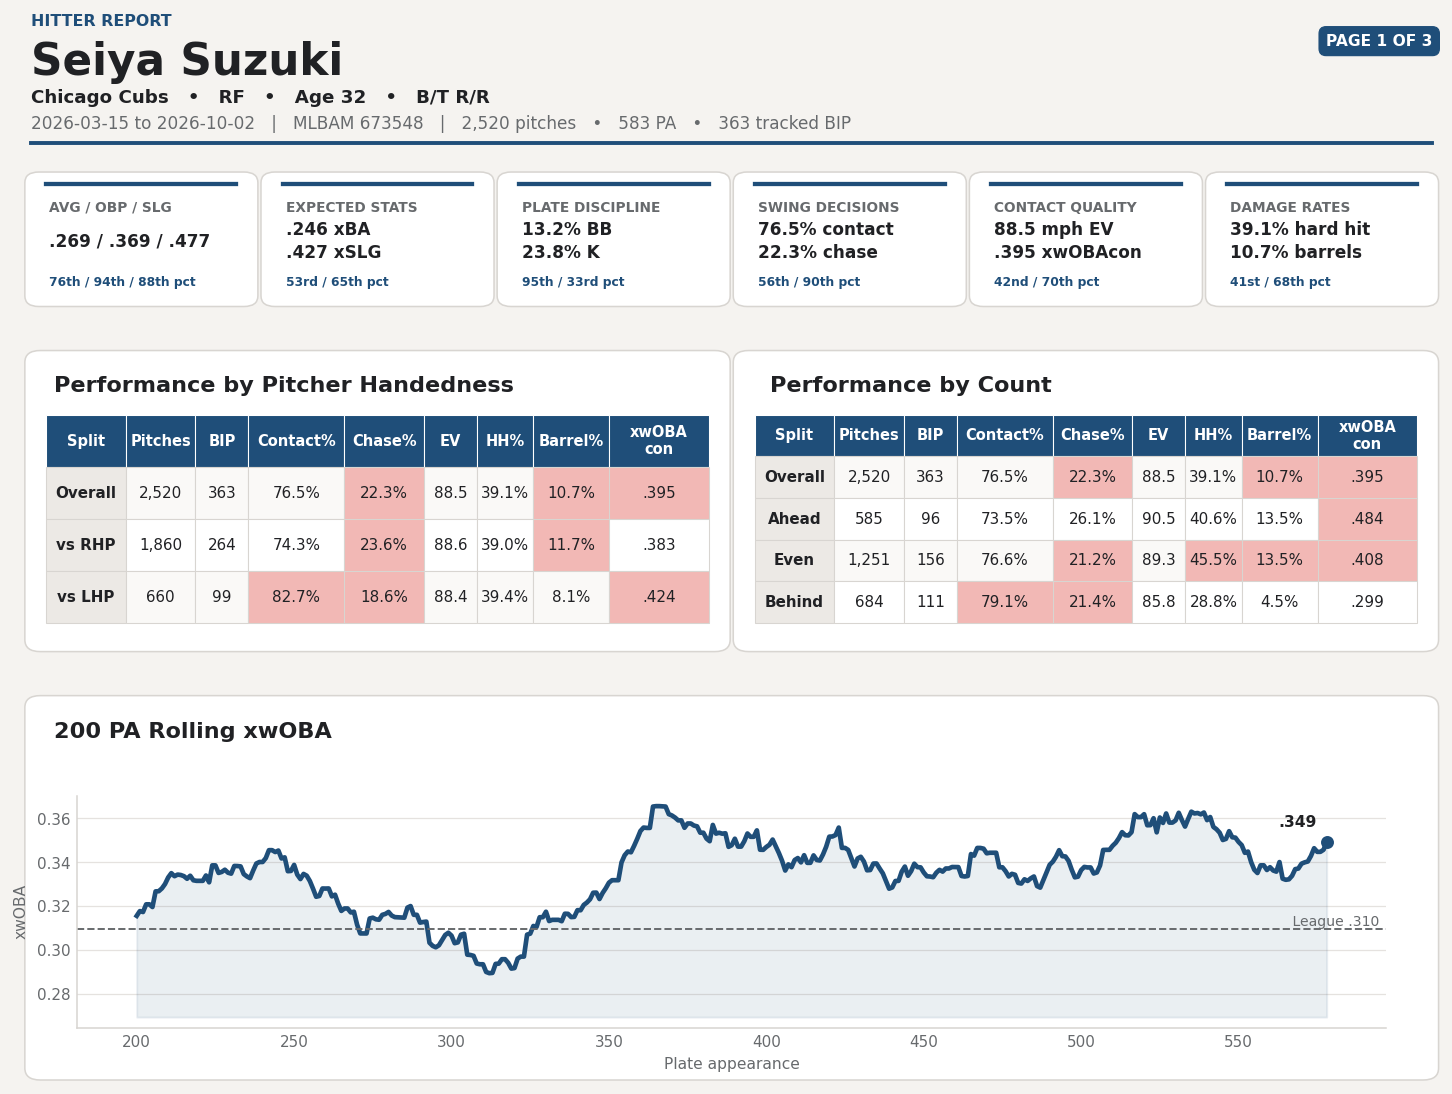

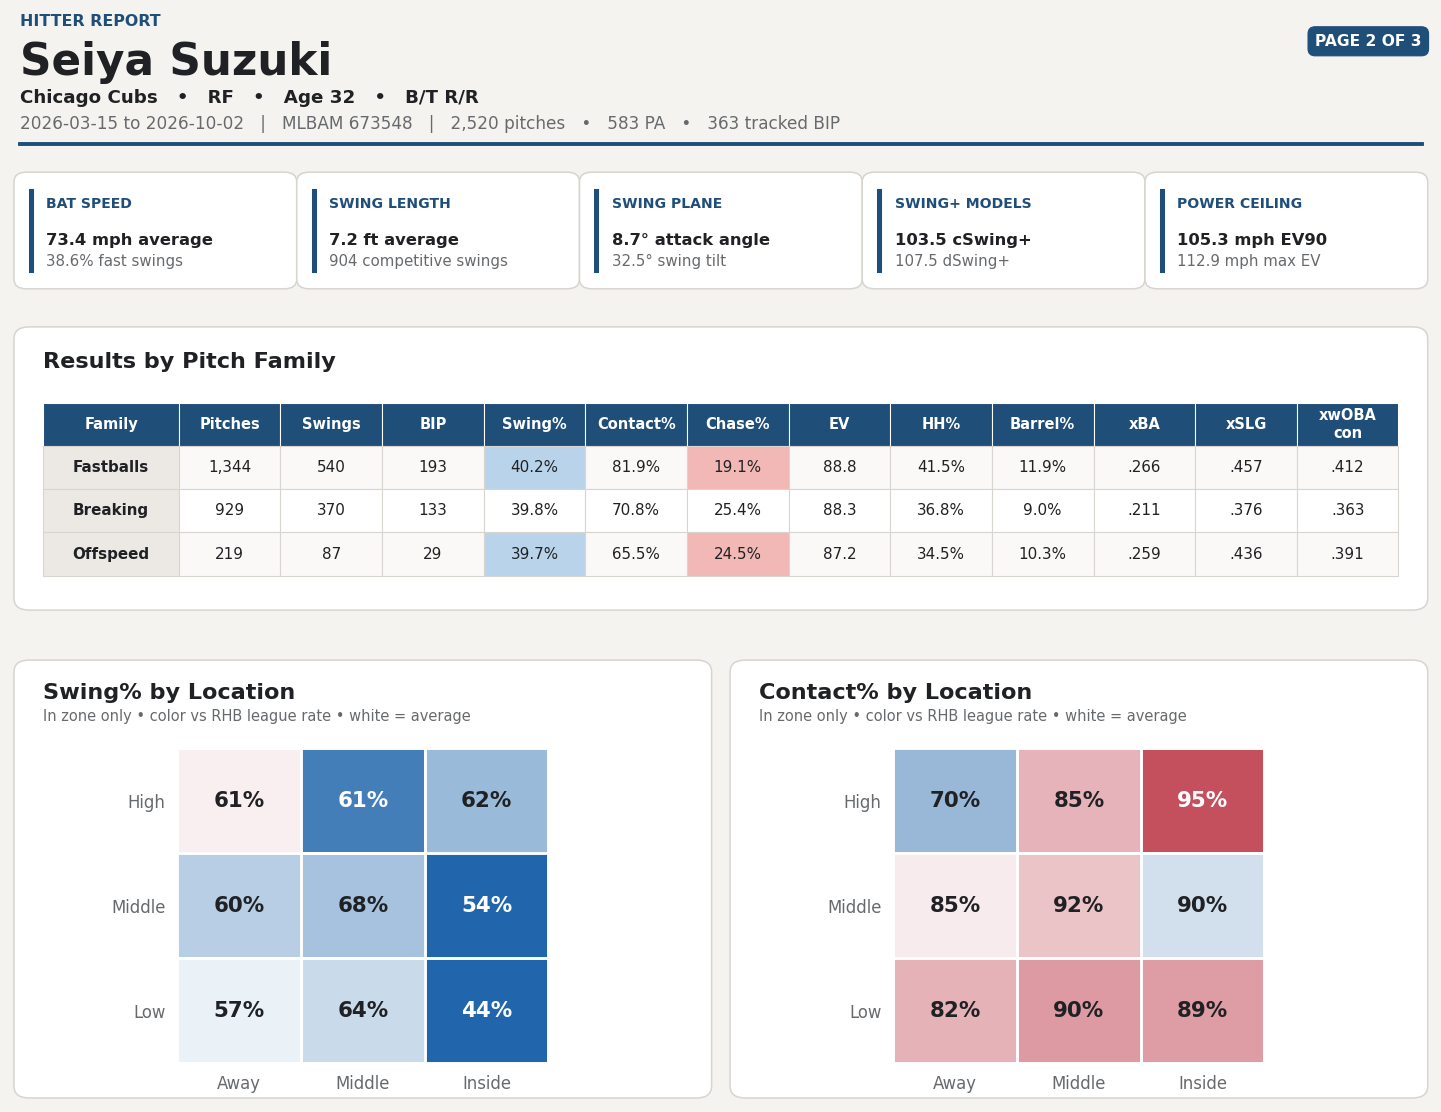

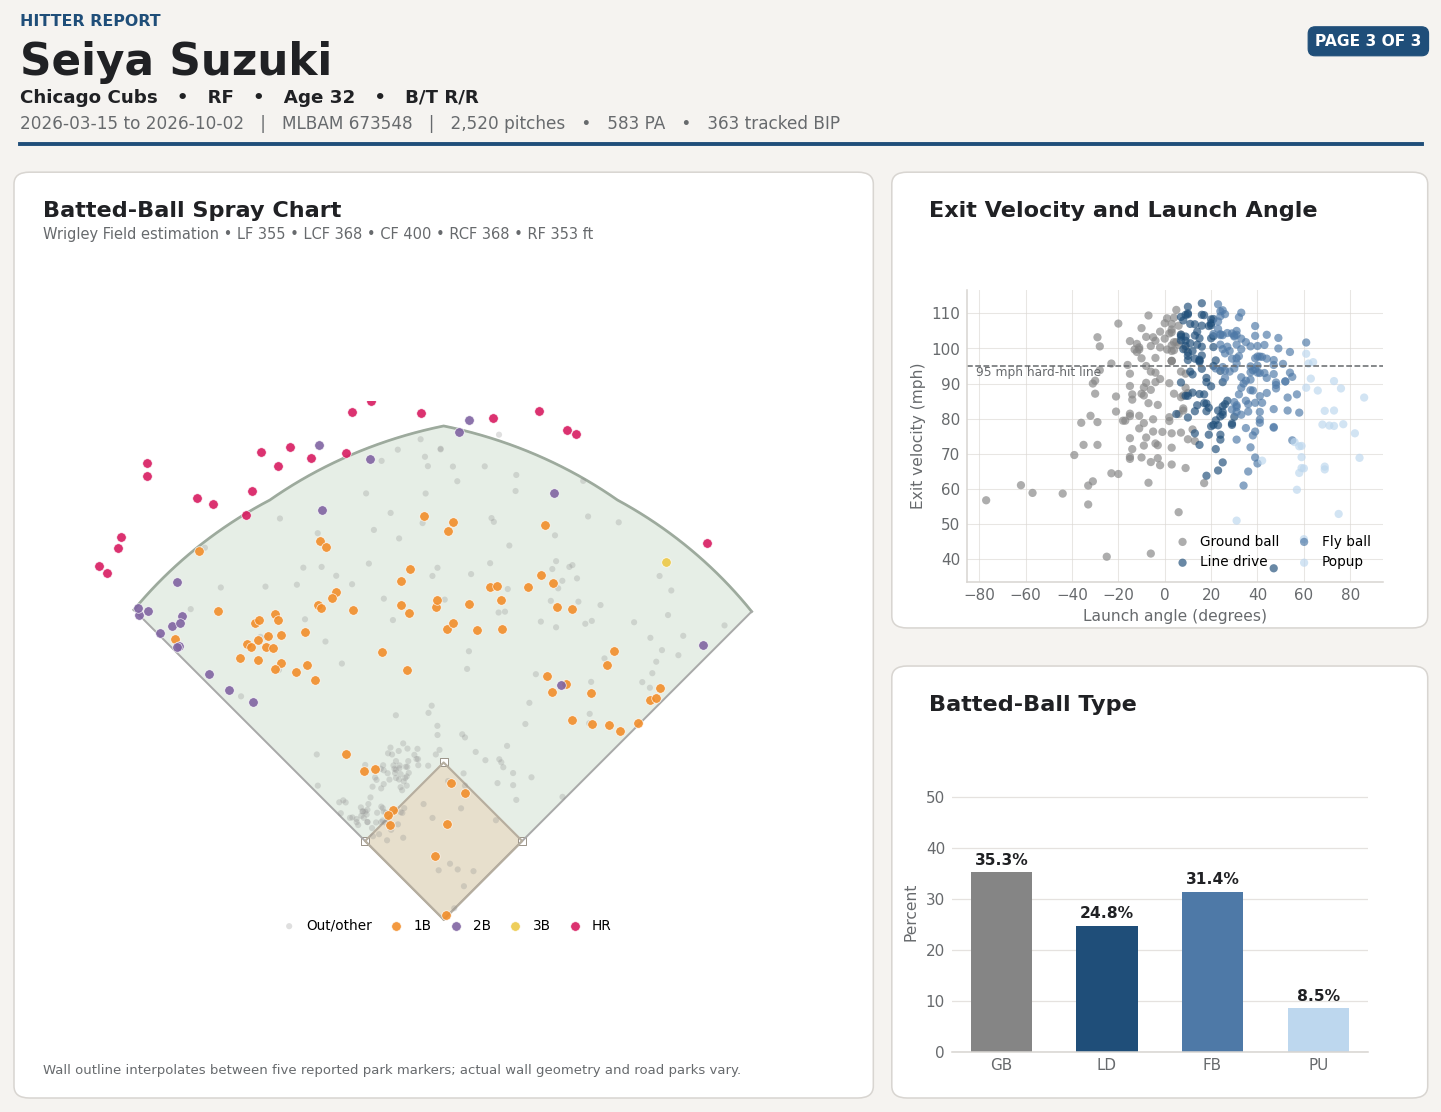

Report complete
PDF: C:\Users\brend\OneDrive\School OneDrive\Jupyter\hitter_reports\seiya_suzuki_2026-3-15_2026-10-02_statcast_hitter_evaluation.pdf
Page 1 PNG: C:\Users\brend\OneDrive\School OneDrive\Jupyter\hitter_reports\seiya_suzuki_2026-3-15_2026-10-02_statcast_hitter_evaluation_page_1.png
Page 2 PNG: C:\Users\brend\OneDrive\School OneDrive\Jupyter\hitter_reports\seiya_suzuki_2026-3-15_2026-10-02_statcast_hitter_evaluation_page_2.png
Page 3 PNG: C:\Users\brend\OneDrive\School OneDrive\Jupyter\hitter_reports\seiya_suzuki_2026-3-15_2026-10-02_statcast_hitter_evaluation_page_3.png
Tables: C:\Users\brend\OneDrive\School OneDrive\Jupyter\hitter_reports\seiya_suzuki_2026-3-15_2026-10-02_statcast_hitter_evaluation_tables.xlsx


In [28]:
player_slug = slugify(PLAYER_NAME)
report_stem = f"{player_slug}_{START_DATE}_{END_DATE}_statcast_hitter_evaluation"
PDF_PATH = OUTPUT_DIR / f"{report_stem}.pdf"
PAGE_1_PATH = OUTPUT_DIR / f"{report_stem}_page_1.png"
PAGE_2_PATH = OUTPUT_DIR / f"{report_stem}_page_2.png"
PAGE_3_PATH = OUTPUT_DIR / f"{report_stem}_page_3.png"
TABLES_PATH = OUTPUT_DIR / f"{report_stem}_tables.xlsx"

page1, page2, page3 = create_report_pages()
with PdfPages(PDF_PATH) as pdf:
    pdf.savefig(page1, facecolor="white")
    pdf.savefig(page2, facecolor="white")
    pdf.savefig(page3, facecolor="white")

page1.savefig(PAGE_1_PATH, dpi=REPORT_DPI, facecolor="white")
page2.savefig(PAGE_2_PATH, dpi=REPORT_DPI, facecolor="white")
page3.savefig(PAGE_3_PATH, dpi=REPORT_DPI, facecolor="white")

with pd.ExcelWriter(TABLES_PATH, engine="openpyxl") as writer:
    overall.to_frame("Value").to_excel(writer, sheet_name="Overall")
    hand_splits.to_excel(writer, sheet_name="By Hand")
    count_splits.to_excel(writer, sheet_name="By Count")
    pitch_splits.to_excel(writer, sheet_name="By Pitch")
    player_pa_xwoba.to_excel(writer, sheet_name="Rolling xwOBA", index=False)
    league_hitter_summaries.to_excel(writer, sheet_name="League Percentiles", index=False)
    pitch_family_benchmarks.to_excel(writer, sheet_name="Pitch Benchmarks", index=False)
    table_split_benchmarks.to_excel(writer, sheet_name="Split Benchmarks", index=False)

plt.show()

print("Report complete")
print(f"PDF: {PDF_PATH.resolve()}")
print(f"Page 1 PNG: {PAGE_1_PATH.resolve()}")
print(f"Page 2 PNG: {PAGE_2_PATH.resolve()}")
print(f"Page 3 PNG: {PAGE_3_PATH.resolve()}")
print(f"Tables: {TABLES_PATH.resolve()}")
